<a href="https://colab.research.google.com/github/anand-me/Spring24VicarMLTutorial/blob/main/Copy_of_SupervisedLearningScikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Scikit Learning**

Read Database of iris

In [ ]:
from sklearn importdatasets  # sklearn is the Python name of scikit-learn
iris = datasets.load_iris()
type(iris)

sklearn.utils._bunch.Bunch

Some command to explore the data

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(iris['target_names']) # or, equivalently, print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
print(iris.DESCR[:500])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                



`data`=measurments or what goes into the ML as input `feature vectors`

In [ ]:
iris.data[:20]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3]])

data matrix (also known as feature matrix).
By convention, scikit-learn assumes this matrix has the shape of sample size × feature size; that is,
the number of observations (also sometimes referred to as the number of samples) × the number of features.

In [ ]:
iris.data.shape

(150, 4)

The three classes in the dataset, namely, setosa, versicolor, and virginica are
encoded as integers 0, 1, and 2, respectively.

In [ ]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

use bincount function from NumPy to count the number of samples in each class:

https://github.com/tirthajyoti/Machine-Learning-with-Python/blob/master/Pandas%20and%20Numpy/Numpy_operations.ipynb

In [ ]:
import numpy as np
np.bincount(iris.target)

array([50, 50, 50])

In [ ]:
print('type of data: ' + str(type(iris.data))+ '\ntype of target: ' + str(type(iris.target)))

type of data: <class 'numpy.ndarray'>
type of target: <class 'numpy.ndarray'>


In [ ]:
print(iris.feature_names) # the name of features

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## **Test Set for Model Assessment**
1. In using scikit-learn, we conventionally use X and y to refer to a data matrix and targets, respectively;
2. Although train_test_split function can receive an arbitrary number of
sequences to split, in supervised learning it is common to use this function with a data matrix and targets only;
3. Although train_test_split function returns a list, it is common to use sequence unpacking to name the results of the split;
4. By default train_test_split function shuffles the data before splitting. This
is a good practice to avoid possible systematic biases in the data; however, to be able to reproduce the results, it is also a good practice to set the seed of random number generator. This is done by setting random_state to an integer;
5. The test_size argument of the function represents the proportion of data that
should be assigned to the test set. The default value of this parameter is 0.25,which is a good rule of thumb if no other specific proportion is desired; and
6. It is a good practice to keep the proportion of classes in both the training and the test sets as in the whole data. This is done by setting the stratify to variable representing the target.

### We use stratified random split to divide the given data into 80% training and 20% test


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(iris.data, iris.target, random_state=100, test_size=0.2, stratify=iris.target)
print('X_train_shape: ' + str(X_train.shape) + '\nX_test_shape: ' + str(X_test.shape)\
+ '\ny_train_shape: ' + str(y_train.shape) + '\ny_test_shape: '+ str(y_test.shape))

X_train_shape: (120, 4)
X_test_shape: (30, 4)
y_train_shape: (120,)
y_test_shape: (30,)


Let us count the number of classspecific
observations in the training data:

In [ ]:
np.bincount(y_train)

array([39, 44, 37])

## **Data Visualization**
We use pandas
https://github.com/tirthajyoti/Machine-Learning-with-Python/blob/master/Pandas%20and%20Numpy/Pandas_Operations.ipynb


In [ ]:
import pandas as pd
X_train_df = pd.DataFrame(X_train, columns=iris.feature_names)
y_train_df = pd.DataFrame(y_train, columns=['class'])
X_y_train_df = pd.concat([X_train_df, y_train_df], axis=1)

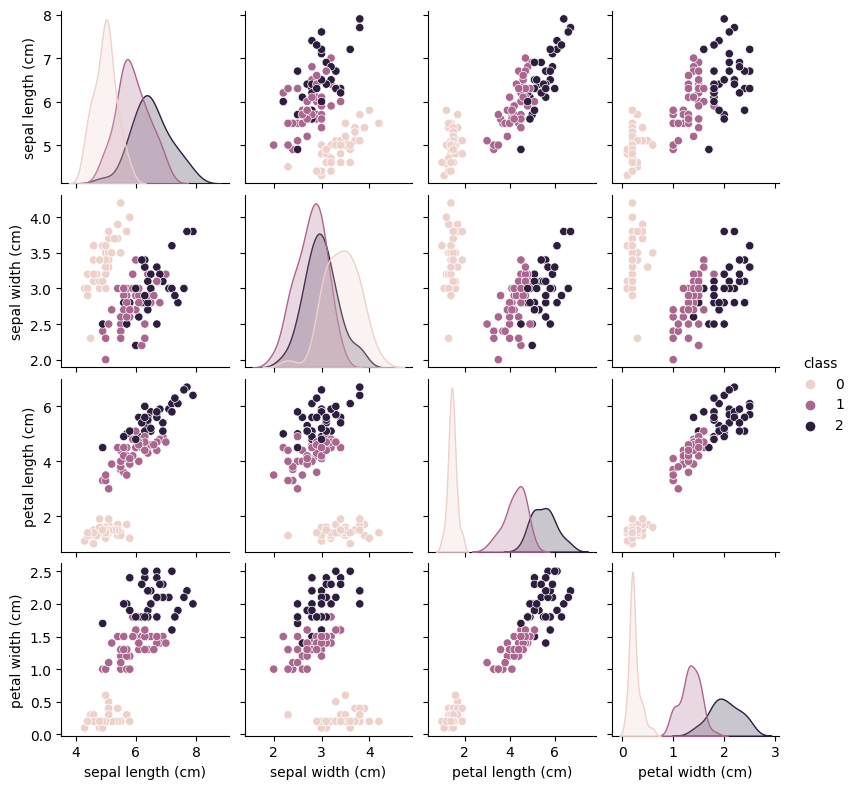

In [ ]:
import seaborn as sns
sns.pairplot(X_y_train_df, hue='class', height=2) # hue is set to the class variable in the dataframe so that they are plotted in different color and we are able to distinguish classes

##**Feature Scaling (Normalization)**
It is always good to scale data. some features could be from 0 to 1, while others may be in the order of thousands or millions depending on what they represent and how they are measured => to make them **comparable**
1. **_standardization_**: use the mean and the standard deviation of each feature so that the feature vector is centered around zero and have a standard deviation of one.
2. **_min-max scaling_** : similar subtraction and division is performed
except that the mean and the standard deviation of each feature are replaced with the minimum and the range (i.e., maximum - minimum) of that feature.


In [ ]:
mean = X_train.mean(axis=0) # to take the mean across rows (for each column)
std = X_train.std(axis=0) # to take the std across rows (for each column)
X_train_scaled = X_train - mean # notice the utility of broadcasting
X_train_scaled /= std  # or similarly X_train_scaled = X_train_scaled/std

In [ ]:
X_train_scaled.mean(axis=0) # observe the mean is 0 now

array([-1.02695630e-15,  3.29366164e-16, -1.14723046e-16, -6.14323407e-16])

In [ ]:
X_train_scaled.std(axis=0) # observe the std is 1 now


array([1., 1., 1., 1.])

In [ ]:
X_test_scaled = X_test - mean
X_test_scaled /= std

In [ ]:
print(X_test_scaled.mean(axis=0))
print(X_test_scaled.std(axis=0))

[0.33859476 0.08449049 0.08643584 0.07965294]
[1.10960327 1.00218051 1.11780629 1.10672817]


Alternative approach is to use scikit-learn transformers for implementing both standardization and min-max scaling.
These are `StandardScaler` (for standardization) and `MinMaxScaler` (for min-max scaling) classes from `sklearn.preprocessing` module.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
def substract_three_numbers ()

We call the `fit() `method of the scaler object (afterall, any
transformer is an estimator and implements the `fit()` method):

In [ ]:
scaler.fit(X_train)

StandardScaler()

We call the `transform()` method of the scaler object
to transform the training and test sets based on statistics extracted from the training set, and use `X_train_scaled` and `X_test_scaled` to refer to the transformed training and test sets, respectively:

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_test_scaled.mean(axis=0)) # observe that we get the same values for the mean and std of test set as in the naive implementation shown above
print(X_test_scaled.std(axis=0))

[0.33859476 0.08449049 0.08643584 0.07965294]
[1.10960327 1.00218051 1.11780629 1.10672817]


For later use and in order to avoid the above preprocessing steps, the training
and testing arrays could be saved using `numpy.save()` to binary files.

could be loaded by `numpy.load()` later

In [ ]:
np.savez('iris_train_scaled', X = X_train_scaled, y = y_train)
np.savez('iris_test_scaled', X = X_test_scaled, y = y_test)

## **Model Training**

Here, we use the *k-nearest neighbors* (kNN) classification rule in its standard
form.

kNN classifier is implemented in the `KNeighborsClassifier` class in the
`sklearn.neighbors module`. Similar to the way we used the `StandardScaler`
estimator earlier, we first instantiate the `KNeighborsClassifier` class into an
object:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier as kNN # giving an alias KNN for simplicity
knn = kNN(n_neighbors=2)    # hyperparameter k is set to 3, that is, we have 3NN

The constructors of many estimators take as arguments various hyperparameters,
which can affect the estimator performance. In case of kNN, perhaps the most
important one is k, which is the number of nearest neighbors of a test point.
In `KNeighborsClassifier` constructor this is determined by `n_neighbors` parameter.Here we set `n_neighbors` to 3, which implies we are using
3NN.

This is for *k=5*

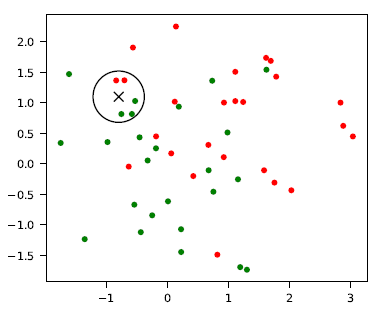


In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

## **Prediction Using the Trained Model**

predictors: that is, they can make
prediction by implementing the `predict()` method.
 `KNeighborsClassifier` is
also a predictor and, therefore, implements `predict()`

In [ ]:
xx_test = np.array([[5.5, 2, 1.1, 0.6]]) # same as: np.array([5.5, 2, 1.1, 0.6]).reshape(1,4)
xx_test.shape

(1, 4)

Recall that scikit-learn always assumes two-dimensional NumPy arrays of shape
sample size × feature size

In [ ]:
xx_test_scaled = scaler.transform(xx_test)
xx_test_scaled

array([[-0.36151502, -2.41950042, -1.53156538, -0.79092008]])

In [ ]:
y_test_prediction = knn.predict(xx_test_scaled)
print('knn predicts: ' + str(iris.target_names[y_test_prediction])) #to convert the prediction (y_test_prediction) to the names of Iris flower

knn predicts: ['versicolor']


We can also give several sample points as the argument to the `predict()`

In [ ]:
y_test_predictions = knn.predict(X_test_scaled)
print('knn predicts: ' + str(iris.target_names[y_test_predictions]))

knn predicts: ['virginica' 'setosa' 'virginica' 'setosa' 'virginica' 'virginica'
 'setosa' 'setosa' 'virginica' 'setosa' 'setosa' 'virginica' 'setosa'
 'setosa' 'virginica' 'versicolor' 'versicolor' 'versicolor' 'virginica'
 'virginica' 'virginica' 'setosa' 'virginica' 'setosa' 'versicolor'
 'virginica' 'versicolor' 'setosa' 'versicolor' 'virginica']


Above sequence of operations, namely, instantiating the class KNN, fitting, and
predicting, can be combined as the following one liner pattern known as *method
chaining*:

In [ ]:
y_test_predictions = kNN(n_neighbors=2).fit(X_train_scaled, y_train).predict(X_test_scaled)
print('knn predicts: ' + str(iris.target_names[y_test_predictions]))

knn predicts: ['virginica' 'setosa' 'virginica' 'setosa' 'virginica' 'virginica'
 'setosa' 'setosa' 'virginica' 'setosa' 'setosa' 'virginica' 'setosa'
 'setosa' 'virginica' 'versicolor' 'versicolor' 'versicolor' 'virginica'
 'virginica' 'virginica' 'setosa' 'versicolor' 'setosa' 'versicolor'
 'virginica' 'versicolor' 'setosa' 'versicolor' 'virginica']


## **Model Evaluation (Error Estimation)**

We can find the probability
of misclassification by the trained classifier.

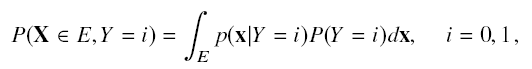

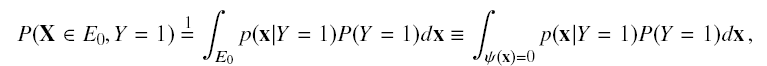

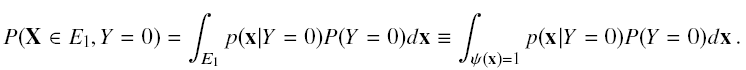

misclasssification
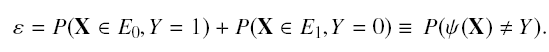

we apply the classifier on a test set $S_{te}$ that contains m observations with
their labels. Let $k$ denote the number of observations in Ste that are misclassified by
the classifier. The test-set error estimate, denoted $\epsilon_{te}$, is given by

$\epsilon_{te}=\frac{k}{m}$

report the accuracy
estimate of a classifier.  $acc=1-\epsilon$

let us calculate the test-set error estimate of our trained kNN classifier

In [ ]:
errors = (y_test_predictions != y_test)
errors

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False])

In [ ]:
error_est = sum(errors)/errors.size
print('The error rate estimate is: {:.2f}'.format(error_est) + '\n'\
'The accuracy is: {:.2f}'.format(1-error_est))

The error rate estimate is: 0.03
The accuracy is: 0.97


Using scikit-learn built-in functions from metrics module many performance
metrics can be easily calculated. A complete list of these metrics supported by scikitlearn is found at https://scikit-learn.org/stable/modules/model_evaluation.html

There are two options that we can use here:
1. using the `accuracy_score` function
2. using the `score method` of the classifier


The `accuracy_score` function expects the actual labels and predicted labels as
arguments:

In [ ]:
from sklearn.metrics import accuracy_score
print('The accuracy is {:.2f}'.format(accuracy_score(y_test,y_test_predictions)))

The accuracy is 0.97


`score` method that given a test data and its
labels, returns the classifier accuracy.

In [ ]:
print('The accuracy is {:.2f}'.format(kNN.score(X_test_scaled, y_test)))

TypeError: ClassifierMixin.score() missing 1 required positional argument: 'y'

## multilayer perceptron (MLP)

#**Deep Learning with Keras-TensorFlow**

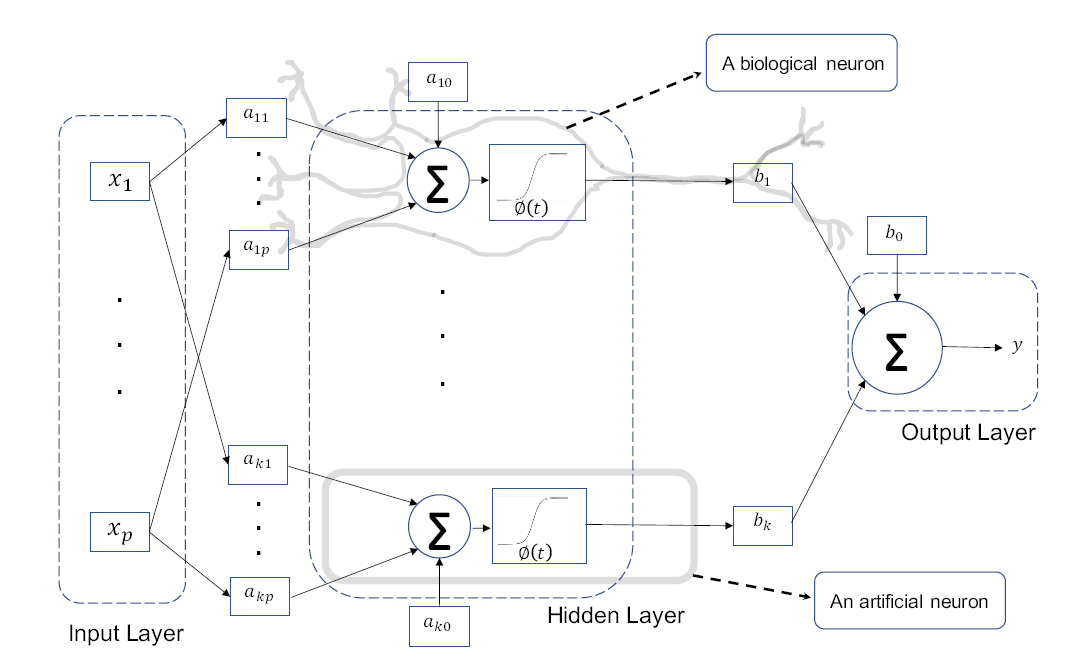

-----
-----
-----

MLP with two hidden layers and $k_1$ and $k_2$ neurons in the first and second
hidden layers.
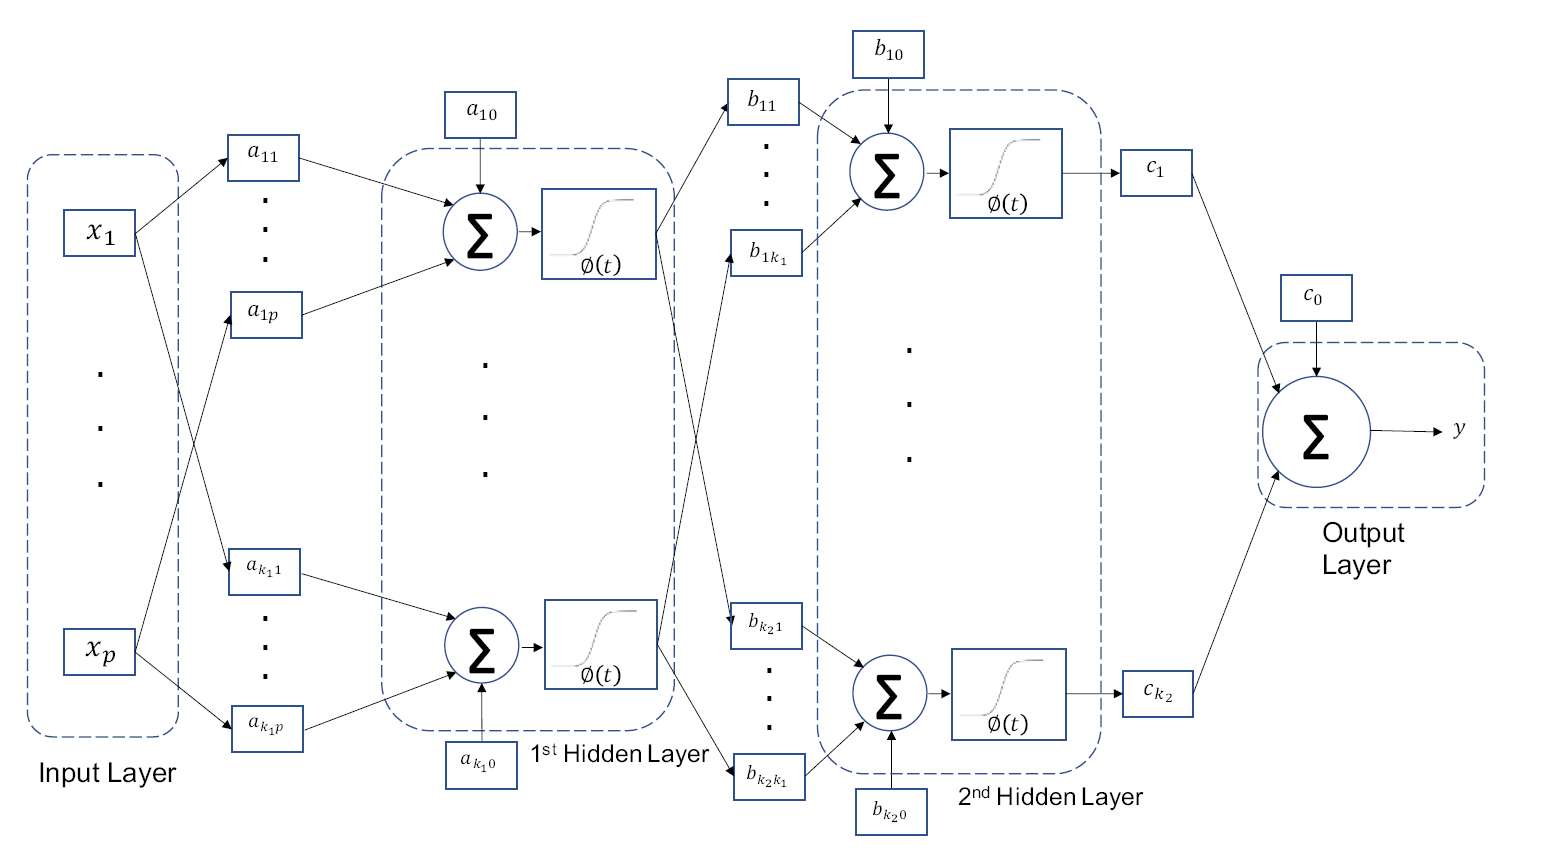



 \begin{align}
f(x) &= c_0+\sum_{l=1}^{k_2} c_l u_l \\
u_l &= \phi(b_{l0}+\sum_{i=1}^{k_1} b_{li} v_i)\,\,\,\,\,\,\, 1\le l\le k_2 \\
v_i &= \phi(a_{i0}+\sum_{j=1}^p a_{ij} x_j)\,\,\,\,\,\,\, 1\le i\le k_1
\end{align}

The general machinery of training an ANN.
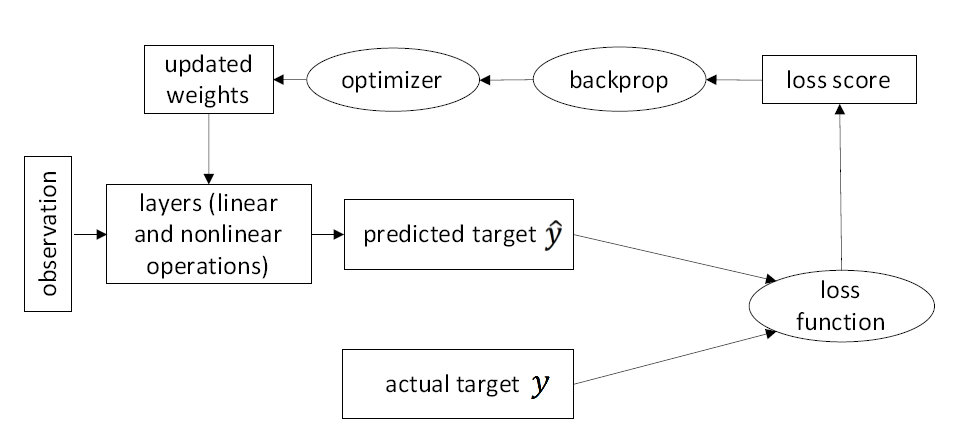

- backpropagation (also referred to as `backprop`), which is essentially based on chain rules of calculus.
- We can compute the value of the gradient of loss function across all training
data, and then update the weights. This is known as `batch` gradient descent.
-  At the same time, a single presentation of the entire training set to the
backprop is called an `epoch`. Therefore, in the batch gradient descent, one update
for the weights occurs at the end of each epoch.
- We can compute the value of the gradient of loss function for a mini training
data (a small subset of training data), and then update the weights. This is known
as `mini-batch` gradient descent. This means
that if we partition a training data of size n into mini-batches of size $K << n$,
then in an epoch we will have [n/K] updates for weights (*batch size*).






In [ ]:
import tensorflow as tf
from tensorflow import keras
import sklearn
print(tf.__version__)
#print(keras.__version__)
print(sklearn.__version__)

2.15.0
1.2.2


The MNIST dataset has a training set of 60,000 grayscale 28 × 28 images of handwritten
digits, and an additional test set of size 10,000. It is part of `keras.dataset`
module and can be loaded as four numpy arrays

In [ ]:
from tensorflow.keras.datasets import mnist

seed_value= 42

# set the seed for Python built-in pseudo-random generator
import random
random.seed(seed_value)

# set the seed for numpy pseudo-random generator
import numpy as np
np.random.seed(seed_value)

# set the seed for tensorflow pseudo-random generator
import tensorflow as tf
tf.random.set_seed(seed_value)

(X_train_val, y_train_val), (X_test, y_test) = mnist.load_data()
print(type(X_train_val))
print(X_train_val.dtype)
print(X_train_val.shape)
print(X_train_val.ndim)

<class 'numpy.ndarray'>
uint8
(60000, 28, 28)
3


In [ ]:
X_train_val, X_test = X_train_val.astype('float32')/255, X_test.astype('float32')/255
print(X_train_val.dtype)

float32


In [ ]:

X_train_val, X_test = X_train_val.reshape(60000, 28*28), X_test.reshape(10000, 28*28)
X_train_val[0].shape


The databse has both test and training

Training Data will be devided inot training and validation data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,stratify=y_train_val,test_size=0.25)

## **Building Model Structure in Keras**
- Method 1: pass a list of layers to `keras.Sequential` class constructor to
instantiate.
-  Method 2: instantiate `keras.Sequential `first with no layer and then use `add()`
method to add layers one after another.

#Method 1:

- use of softmax in the last layer is due to the
multiclass (single label) nature of this classification problem.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
mnist_model = keras.Sequential([
                        layers.Dense(128, activation="sigmoid"),
                        layers.Dense(64, activation="sigmoid"),
                        layers.Dense(10, activation="softmax")
                     ])
 #mnist_model.weights # if we uncomment this code and try to run it at this stage, an error is raised because the weights are not set (the model is not actually built yet)

## Method2:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

mnist_model = keras.Sequential()
mnist_model.add(layers.Dense(128, activation="sigmoid"))
mnist_model.add(layers.Dense(64, activation="sigmoid"))
layers.Dense(10, activation="softmax")

The codes presented in Method 1 or Method 2 do not build the model in the strict
sense. This is because “building” a model means setting the weights of layers, but
the number of weights depends on the input size, which is not given in the above
codes. In that case, the model will be built as soon as it is called on some data (for
example, using `fit()` method)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

mnist_model = keras.Sequential([
                        layers.Dense(128, activation="sigmoid",input_shape = X_train[0].shape),
                        layers.Dense(64, activation="sigmoid"),
                        layers.Dense(10, activation="softmax")
                    ])

In [ ]:
mnist_model.weights # the weights are initialized (the biases to 0 and the rest randomly)

[<tf.Variable 'dense_18/kernel:0' shape=(784, 128) dtype=float32, numpy=
 array([[ 0.05125348,  0.02213316,  0.00018936, ..., -0.02790708,
         -0.02995578, -0.07027635],
        [ 0.07122812,  0.04648923,  0.07214008, ...,  0.00730932,
          0.06999829, -0.04747489],
        [ 0.03707027, -0.07622411, -0.02594069, ..., -0.01777372,
          0.0511134 , -0.06212196],
        ...,
        [ 0.02109967,  0.013035  , -0.03989777, ..., -0.01553821,
          0.03680419, -0.05935369],
        [ 0.06091972,  0.07541282,  0.03700751, ..., -0.08061466,
         -0.04764071, -0.06120547],
        [-0.01695693,  0.07909713,  0.06635126, ...,  0.07532718,
          0.05138486,  0.02404693]], dtype=float32)>,
 <tf.Variable 'dense_18/bias:0' shape=(128,) dtype=float32, numpy=
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

We can use `summary()` method that tabulates the shape of output and the total
number of parameters that are/should be estimated in each layer.

In [ ]:
mnist_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 128)               100480    
                                                                 
 dense_19 (Dense)            (None, 64)                8256      
                                                                 
 dense_20 (Dense)            (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##Compiling: optimizer, metrics, and loss

Compiling in Keras is the process of configuring the learning process via `compile()` methodof `keras.Model` class.

Some possible common choices for classification and regression:
- `optimizer`$^1$ :for example,
`optimize = keras.optimizers.Adam(learning_rate=0.01)` using
whichwe are changing the 0.001 default value of learning_rate used inAdam
optimizer to 0.01.
- `metrics`$^2$ : can be set by replacing name(s) in `metrics = [name(s)]`. for example,
`metrics = ["mean_squared_error", "mean_absolute_error"]` is
equivalent to

```
metrics = [keras.metrics.MeanSquaredError(),
          keras.metrics.MeanAbsoluteError()]
```
- `loss`$^3$ : can be set by replacing name in `loss = name`.
> > - `binary_crossentropy` (for binary classification aswell as multilabel classification, which more than one label is assigned to an instance);
> > -  `categorical_crossentropy` (for multiclass classification when target
values are one-hot encoded);
> > - `sparse_categorical_crossentropy` (for multiclass classification when
target values are integer encoded),
> > - `mean_squared_error` and `mean_absolute_error` for regression.

For example, `loss = keras.losses.BinaryCrossentropy() ` is equivalent to `loss= binary_crossentropy`.


$^1$: Keras-optimizers (2023). https://keras.io/api/optimizers/, Last accessed
on 2023-02-15.

$^2$: Keras-metrics (2023). https://keras.io/api/metrics/, Last accessed on
2023-02-15.

$^3$: Keras-losses (2023). https://keras.io/api/losses/, Last accessed on 2023-02-15.


In [ ]:
true_classes = [0, 1, 1] # actual labels
class_probs_per_obs = [[0.9, 0.1], [0.2, 0.8], [0.4, 0.6]] # the outputs of softmax for two neurons
scce = tf.keras.losses.SparseCategoricalCrossentropy()
scce(true_classes, class_probs_per_obs).numpy()

0.27977657

In [ ]:
true_classes = [0, 1, 1]
class_1_prob_per_obs = [0.1, 0.8, 0.6] # the outputs of sigmoid for one neuron
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
bce(true_classes, class_1_prob_per_obs).numpy()

0.2797764

We now compile the previously built `mnist_model`. Although the labels stored in `y_train, y_val, and y_test` are already integer encoded (and we can use `sparse_categorical_crossentropy` to compile the model), here we show the utility of `to_categorical()` for one-hot encoding and, therefore, we use `categorical_crossentropy` to compile the model:

In [ ]:
mnist_model.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
y_train_1_hot = keras.utils.to_categorical(y_train, num_classes = 10)
y_val_1_hot = keras.utils.to_categorical(y_train_val, num_classes = 10)
y_test_1_hot = keras.utils.to_categorical(y_test, num_classes = 10)
print(y_train.shape)
print(y_train_1_hot.shape)

(45000,)
(45000, 10)


##`Categorical_crossentropy and sparse_categorical_crossentropy:`

depending on whether we use one-hot encoded labels or integer encoded labels, we need to use either the categorical_crossentropy or the
sparse_categorical_crossentropy.

Suppose for a multiclass (single label) classification with c classes, a training
data $S_{tr} = \{(\mathbf{x}_1; y_1), (\mathbf{x}_2; y_2),..., (\mathbf{x}_n; y_n)\}$ is available. Applying one-hot encoding on
$y_j; j = 1,...,n,$ leads to label vectors $\mathbf{y}_j = [y_{j0},..., y_{j(c−1)}]$ where $y_{ji} \in \{0; 1\}, i =0,...,c − 1.$
Categorical cross-entropy (also known as cross-entropy) is defined as

\begin{align}
e(\mathbf{\theta})= -\frac{1}{n} \sum_{j=1}^{n}\sum_{i=0}^{c-1} y_{ji} \text{log}\left( P(Y_j=i|\mathbf{x}_j;\mathbf{\theta}\right)
\end{align}
or
\begin{align}
e(\mathbf{\theta})= -\frac{1}{n} \sum_{j=1}^{n}\ \mathbf{y}_{j}^T \text{log}\left(\mathbf{p}_j\right)
\end{align}


The sparse_categorical_crossentropy implements
a similar function except that rather than one-hot encoded labels, it expects integer encoding with labels $y_j$ in the range of $0, 1, ...,c − 1$ with $p_j=P(Y_j=y_j|\mathbf{x}_j;\mathbf{\theta})$. This
way, we can write (sparse) cross-entropy as:

\begin{align}
e(\mathbf{\theta})= -\frac{1}{n} \sum_{j=1}^{n}\text{log}\left({p}_{j\,y_j}\right)
\end{align}


Example: Suppose we have a class label with possible values, Red, Blue,
and Green. We use one-hot encoding and represent them as Red : [1; 0; 0] ,
Blue : [0; 1; 0] , and Green : [0; 0; 1] . Two observations $x_1$ and $x_2$ are presented
to an ANN with some values for its weights. The true classes of $x_1$ and $x_2$ are
Green and Blue, respectively. The output of the network after the softmax for $x_1$ is
[0:1; 0:4; 0:5] and its output for $x_2$ is [0:05; 0:8; 0:15] . What is the cross-entropy?

The classes of x1 and x2 are [0; 0; 1] and [0; 1; 0], respectively; that is, y1 =[0; 0; 1] and y2 = [0; 1; 0] . At the same time, p1 = [0:1; 0:4; 0:5] and p2 =
[0:05; 0:8; 0:15]

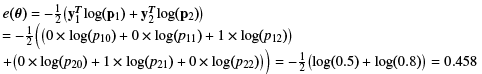


In [ ]:
from tensorflow import keras
labels_one_hot = [[0, 0, 1], [0, 1, 0]]
class_probs_per_obs = [[0.1, 0.4, 0.5], [0.05, 0.8, 0.15]]
cce = keras.losses.CategoricalCrossentropy()
cce(labels_one_hot, class_probs_per_obs).numpy()

For the sparse categorical cross-entropy, the labels are expected to be integer
encoded; that is to say, y1 = 2 and y2 = 1. Therefore, we can pick the corresponding
probabilities at index 2 and 1 (assuming the first element in each probability vector
has index 0) from p1 and p2, respectively, to write

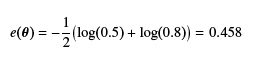

In [ ]:
labels = [2, 1]
class_probs_per_obs = [[0.1, 0.4, 0.5], [0.05, 0.8, 0.15]]
scce = keras.losses.SparseCategoricalCrossentropy()
scce(labels, class_probs_per_obs).numpy()

# Fitting
Once a model is compiled, training the model is performed by calling the `fit()`
method of `keras.Model class`.

important paramaters of the `fit()`
1. `x`: represents the training data matrix;
2. `y`: represents the training target values;
3. `batch_size`: can be used to set the batch size used in the mini-batch gradient
descent;
4. `epochs`: can be used to set the number of epochs to train the model;
5. `validation_data`: can be used to specify the validation set and is generally in
the form of (`x_val, y_val`);
6. `steps_per_epoch`: this is used to set the number of batches processed per
epoch. The default value is None, which for a batch size of $K$, sets the number
of batches per epoch to the conventional value of $[n/K]$ where $n$ is the sample
size. This option would be helpful when $n$ is such a large number that each epoch may take a long time if $[n/K]$ is used;
7. `callbacks_list`: a list of callback objects. A callback is an object that is called
at various stages of training to take an action. There are several callbacks implemented
in Keras but a combination of the following two is quite handy in many
cases
 - `keras.callbacks.EarlyStopping(monitor="val_loss",patience=0)` : Using this callback, we stop training after a monitored metric (`monitor` parameter)
does not improve after a certain number of epochs (`patience`).
 - `keras.callbacks.ModelCheckpoint(filepath="file_path.keras", monitor="val_loss", save_best_only=False, save_freq="epoch")`. By default, this callback saves the model at the end of each epoch. This default
behaviour could be changed by setting `save_freq` to an integer in which case
the model is saved at the end of that many batches. We
 often desire
to save the best model at the end of epoch if the monitored metric (`monitor`) is
improved. This behaviour is achieved by `save_best_only=True`.We
can also set `verbose` to 1 to see additional information




Here we first prepare a list of callbacks and then train our previously compiled model

In [ ]:
import time
my_callbacks = [
            keras.callbacks.EarlyStopping(
                  monitor="val_accuracy",
                  patience=20),
            keras.callbacks.ModelCheckpoint(
                  filepath="model/best_model.keras",
                  monitor="val_loss",
                  save_best_only=True,
                  verbose=1)
              ]

start = time.time()


history = mnist_model.fit(x = X_train,
                y = y_train_1_hot,
                batch_size = 32,
                epochs = 200,
                validation_data = (X_val, y_val_1_hot),
                callbacks = my_callbacks)
end = time.time()
training_duration = end - start
print("training duration = {:.3f}".format(training_duration))

Epoch 1/200
1401/1407 [============================>.] - ETA: 0s - loss: 0.3587 - accuracy: 0.8949

ValueError: Data cardinality is ambiguous:
  x sizes: 15000
  y sizes: 60000
Make sure all arrays contain the same number of samples.

In [ ]:
import matplotlib.pyplot as plt
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4))
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label ='validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label ='training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label ='validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')

##Evaluating and Predicting

We can evaluate the performance of a trained network on a given test data using
the `evaluate()` method of `keras.Model` class

we generally wish to
use the “best” model; that is, the model that led to the best value of metric
used in `callbacks.ModelCheckpoint(monitor=metric)`. Note that this is the
model saved at the end of the training process if `ModelCheckpoint` is used with
`save_best_only=True`.

In [ ]:
# load and evaluate the "best" model
best_mnist_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_mnist_model.evaluate(X_test, y_test_1_hot,verbose=1)
print('Test accuracy of the model with lowest loss on validation set (the best model) = {:.3f}'.format(accuracy))

we can use `predict() `method of` keras.Model` class to obtain probabilitites
of an observation belonging to a class.

In [ ]:
prob_y_test_pred = best_mnist_model.predict(X_test)
print("the size of predictions is (n_sample x n_classes):",prob_y_test_pred.shape)
print("class probabilitites for the first instance:\n",prob_y_test_pred[0])
print("the assigned class for the first instance is: ",prob_y_test_pred[0].argmax()) # the one with the highest probability
print("the actual class for the first instance is: ", y_test_1_hot[0].argmax())
y_test_pred = prob_y_test_pred.argmax(axis=1)
print("predicted classes for the first 10 isntances:", y_test_pred[:10])

for small number of test data, we can use `model(x):`

In [ ]:
prob_y_test_pred = best_mnist_model(X_test).numpy() # calling numpy() on a tensorflow tensor creates numpy arrays
print("the size of predictions is (n_sample x n_classes):",prob_y_test_pred.shape)
print("class probabilitites for the first instance:\n",prob_y_test_pred[0])
print("the assigned class is: ", prob_y_test_pred[0].argmax()) # the one with the highest probability
print("the actual class is: ", y_test_1_hot[0].argmax())
y_test_pred = prob_y_test_pred.argmax(axis=1)
print("predicted classes for the first 10 isntances:", y_test_pred[:10])

We can use various classes of sklearn.metrics to evaluate the final model using different metrics

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,roc_auc_score
print("Accuracy = {:.4f}".format(accuracy_score(y_test, y_test_pred)))
print("Confusion Matrix is\n {}".format(confusion_matrix(y_test,y_test_pred)))
print("Macro Average ROC AUC = {:.3f}".format(roc_auc_score(y_test,prob_y_test_pred, multi_class='ovr', average='macro')))

Above we can imporve the robustness by `Dropout`

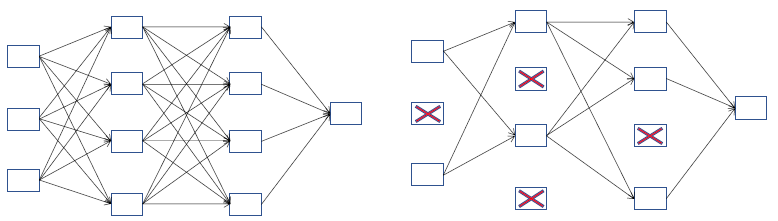

an MLP when no dropout is used and an MLP when a dropout is used

Epoch 1/200
1395/1407 [============================>.] - ETA: 0s - loss: 0.7428 - accuracy: 0.7849
Epoch 1: val_loss improved from inf to 0.29001, saving model to best_model.keras
1407/1407 [==============================] - 9s 6ms/step - loss: 0.7395 - accuracy: 0.7859 - val_loss: 0.2900 - val_accuracy: 0.9133
Epoch 2/200
1401/1407 [============================>.] - ETA: 0s - loss: 0.3268 - accuracy: 0.9072
Epoch 2: val_loss improved from 0.29001 to 0.21346, saving model to best_model.keras
1407/1407 [==============================] - 7s 5ms/step - loss: 0.3265 - accuracy: 0.9072 - val_loss: 0.2135 - val_accuracy: 0.9346
Epoch 3/200
1406/1407 [============================>.] - ETA: 0s - loss: 0.2609 - accuracy: 0.9260
Epoch 3: val_loss improved from 0.21346 to 0.17704, saving model to best_model.keras
1407/1407 [==============================] - 8s 6ms/step - loss: 0.2609 - accuracy: 0.9260 - val_loss: 0.1770 - val_accuracy: 0.9447
Epoch 4/200
1406/1407 [============================>.

Text(0.5, 0, 'epoch')

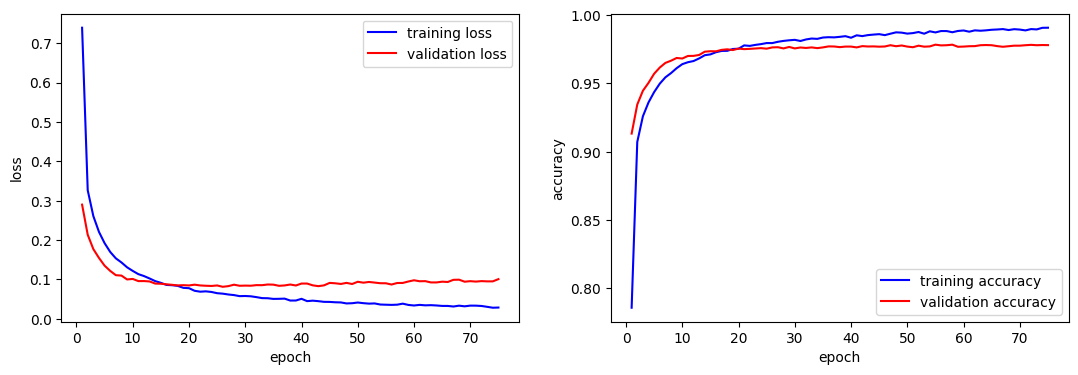

In [ ]:
import time
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

seed_value= 42

# set the seed for Python built-in pseudo-random generator
import random
random.seed(seed_value)
# set the seed for numpy pseudo-random generator
import numpy as np
np.random.seed(seed_value)

# set the seed for tensorflow pseudo-random generator
import tensorflow as tf
tf.random.set_seed(seed_value)

# data preprocessing
(X_train_val, y_train_val), (X_test, y_test) = mnist.load_data()
X_train_val, X_test = X_train_val.astype('float32')/255, X_test.astype('float32')/255
X_train_val, X_test = X_train_val.reshape(60000, 28*28), X_test.reshape(10000, 28*28)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val, stratify=y_train_val, test_size=0.25)

y_train_1_hot = keras.utils.to_categorical(y_train, num_classes = 10)
y_val_1_hot = keras.utils.to_categorical(y_val, num_classes = 10)
y_test_1_hot = keras.utils.to_categorical(y_test, num_classes = 10)

# building model
mnist_model = keras.Sequential([
    layers.Dense(128, activation="sigmoid",input_shape = X_train[0].shape),
    layers.Dropout(0.3),
    layers.Dense(64, activation="sigmoid"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
    ])


# compiling model
mnist_model.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])


# training model
my_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20),
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1)
    ]

start = time.time()

history = mnist_model.fit(x = X_train,
    y = y_train_1_hot,
    batch_size = 32,
    epochs = 200,
    validation_data = (X_val, y_val_1_hot),
    callbacks=my_callbacks)

end = time.time()
training_duration = end - start
print("training duration = {:.3f}".format(training_duration))
print(history.history.keys())
print(mnist_model.summary())


# plotting the results
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4))
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label ='validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label ='training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label ='validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')


In [ ]:
best_mnist_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_mnist_model.evaluate(X_test, y_test_1_hot,verbose=1)
print('Test accuarcy of the dropout model with lowest loss (the best model) = {:.3f}'.format(accuracy))

313/313 [==============================] - 1s 2ms/step - loss: 0.0797 - accuracy: 0.9760
Test accuarcy of the dropout model with lowest loss (the best model) = 0.976


##Hyperparameter Tuning

a major bottleneck in using deep neural networks is the large number of hyperparameters to tune. Although `Keras-TensorFlow` comes with
several tuning algorithms, here we discuss the use of grid search cross-validation implemented
by `sklearn.model_selection.GridSearchCV`

The procedure can be used with random search cross-validation if `GridSearchCV` and `param_grid` are replaced with
`RandomizedSearchCV` and `param_distributions`


We can vary the number
of layers and neurons (structural) hyperparameters to tune the model. we first write a
function, called `construct_model`, which constructs and compiles a sequential Keras model depending on the number of layers and neurons in each layer.

Then treating `construct_model` as the argument of `KerasClassifier`, we create the classifier that can be treated as a scikit-learn estimator; for example, to use it within `GridSearchCV` or, if needed, as the classifier used within `Pipeline` class to create
a composite estimator along with other processing steps.


Here, we  treat the dropout rate of the optimizer as well as the number of epochs as two additional hyperparameters to tune. In contrast with `EarlyStopping` callback, we determine the epoch that jointly with other hyperparameters leads to the
highest CV score.
For that reason, and to reduce the computational complexity of the grid search, we assume candidate epoch values are in the set {10; 30; 50; 70}.


In [ ]:
def construct_model(hidden_layers = 2, neurons=32,learning_rate = 0.001):
# building model
    model = keras.Sequential()
    for i in range(hidden_layers):
        model.add(layers.Dense(units=neurons, activation="sigmoid"))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(10, activation="softmax"))
    # compiling model
    model.compile(loss='categorical_crossentropy',
          optimizer=keras.optimizers.Adam(learning_rate),
          metrics=['acc'])
    return model

In [ ]:
import time
import pandas as pd
import scikeras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
##from keras.wrappers.scikit_learn import KerasClassifier, KerasRegressor
from sklearn.model_selection import StratifiedKFold, GridSearchCV

seed_value= 42


# set the seed for Python built-in pseudo-random generator
import random
random.seed(seed_value)

# set the seed for numpy pseudo-random generator
import numpy as np
np.random.seed(seed_value)


# set the seed for tensorflow pseudo-random generator
import tensorflow as tf
tf.random.set_seed(seed_value)


# data preprocessing
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train.astype('float32')/255, X_test.astype('float32')/255
X_train, X_test = X_train.reshape(60000, 28*28), X_test.reshape(10000,28*28)

strkfold = StratifiedKFold(n_splits=3, shuffle=True)
keras_est = KerasClassifier(build_fn=construct_model, verbose=1)
param_grid = {'epochs': range(10,90,20)}
gscv = GridSearchCV(keras_est, param_grid, cv=strkfold)


# training model
score_best_estimator=gscv.fit(X_train, y_train).score(X_test, y_test)


#best model based on grid search cv
print('the highest CV score is: {:.3f}'.format(gscv.best_score_))
print('the best combination is: {}'.format(gscv.best_params_))
print('the accuracy of the best estimator on the test data is: {:.3f}'.format(score_best_estimator))

/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/scikeras

ValueError: 
All the 12 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 1491, in fit
    super().fit(X=X, y=y, sample_weight=sample_weight, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 760, in fit
    self._fit(
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 926, in _fit
    self._check_model_compatibility(y)
  File "/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py", line 549, in _check_mode

by looking into
`gscv.cv_results_  `attribute, we can present
the fold-specific CV scores and the overall CV score for all combinations of hyperparameter values. As we can see, the highest `mean_test_score` is 0.972 similaer to `gscv.best_score_`:

In [ ]:
pd.options.display.float_format = '{:,.3f}'.format
df = pd.DataFrame(gscv.cv_results_)
df

# Convolutional NN

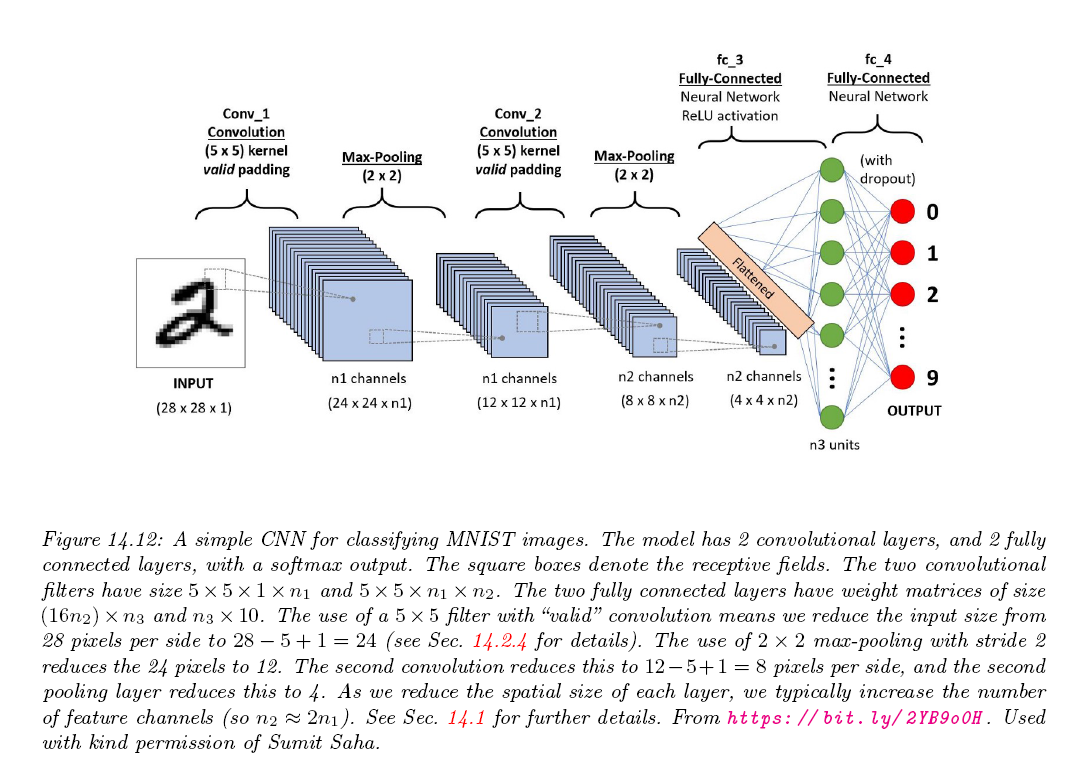

##Kernel

$y[m] = (x*K)[m]= \sum_{i=-\infty}^{\infty} x[i] K[m-i] =(in ML)= \sum_{i=-\infty}^{\infty} x[i] K'[m+i]$

The ML try to learn K or equivalently K'

## general Info for Keras implementation
**The layers of CNN**: to add 2D convolutional layer in Keras, we can use
keras.layers.Conv2D class. The number of filters (number of output feature
maps), kernel size $(h_K \times w_K)4, the strides (along the height and the width),
and padding are set through the following parameters:

`keras.layers.Conv2D(filters, kernel_size,strides=(1, 1), padding="valid")`

where `kernel_size` and `strides` can be either a tuple/list of 2 integers that is
applied to height and width directions, respectively, or one integer that is applied
to both directions. The default `padding="valid"` causes no padding. Changing
that to `padding="same"` results in zero padding;

**MaxPooling** to add max-pooling, we can add

`keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(1, 1), padding="valid")`.
pool_size can be either a tuple/list of 2 integers that shows the height and
width of the pooling window, or one integer that is then considered as the size
in both dimensions;

**Activation Function**
a recommended
activation function in convolutional layers is ReLU;

**Classification Part at The end**
the “classification” part: convolutional layers act like feature detectors (extractors).
Regardless of whether we use one or more convolutional layers, we end up
with a number of feature maps, which is determined by the number of filters in
the last convolutional layer. The question is how to perform classification with
these feature maps. There are two options:
- flattening the feature maps of the last convolutional layer using a flattening
layer (layers.Flatten) and then use the results as feature vectors to train
fully connected layers similar to what we have seen. Although
this practice is common, there are two potential problems. One is that due to
large dimensionality of these feature vectors, the fully connected layer used
here could potentially overfit the data. For this reason, it is recommended to
use dropout in this part to guard against overfitting. Another problem is that
the fully connected layers used in this part have their own hyperparameters
and tuning them entails an increase in the computational needs;
- apply the **global average pooling**  after the last convolutional
layer. This can be done using `keras.layers.GlobalAveragePooling2D`.
At this stage,we have two options for the number of filters in the last convolutional
layer:
    1. we can set the number of filters in the last layer to the number
of categories and then use a softmax layer (`keras.layers.Softmax()`)
to convert the global average of each feature map as the probability of the
corresponding class for the input;
    2. use the number of filters in the last
layer as we genereally use in CNNs (e.g., increasing the number of filters as
we go deeper in the CNN), and then apply the global average pooling. As
this practice leads to a larger vector than the number of classes (one value
per feature map), we can then use that as the input to a fully connected layer
that has a softmax activation and a number of neurons equal to the number
of classes.

Flattened feature maps of the last convolutional layer as the input to two
fully connected layers in the “classification” part of the network trained for the
MNIST application.

In [ ]:
import time
import numpy as np
from tensorflow  import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split


seed_value=43

#random generator
import random
random.seed(seed_value)

# same for numpy
np.random.seed(seed_value)

# same for tensorflow
tf.random.set_seed(seed_value)


(X_train_val, y_train_val), (X_test, y_test) = mnist.load_data()
#scaling to be between 0 and 1 as float
X_train_val, X_test = X_train_val.astype('float32')/255, X_test.astype('float32')/255


#make the images 3D
X_train_val=X_train_val[:,:,:,np.newaxis]
X_train_val[0].shape
X_test=X_test[:,:,:,np.newaxis]

X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,stratify=y_train_val,test_size=0.25)
y_train_1_hot=keras.utils.to_categorical(y_train, num_classes=10)
y_val_1_hot=keras.utils.to_categorical(y_val, num_classes=10)
y_test_1_hot=keras.utils.to_categorical(y_test, num_classes=10)


array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=float32)

keras.layers.Conv2D(filters, kernel_size,strides=(1, 1), padding="valid")

In [ ]:
mnist_model = keras.Sequential([
                              layers.Conv2D(16, 3, activation="relu",input_shape = X_train[0].shape),
                              layers.MaxPooling2D(),
                              layers.Conv2D(64, 3, activation="relu"),
                              layers.MaxPooling2D(),
                              layers.Flatten(),
                              layers.Dropout(0.3),
                              layers.Dense(32, activation="relu"),
                              layers.Dropout(0.3),
                              layers.Dense(10, activation="softmax")
                                 ])


# compiling model
mnist_model.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])



# training model
my_callbacks = [
              keras.callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=5),
              keras.callbacks.ModelCheckpoint(
                    filepath="best_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=1)
              ]

start = time.time()

history = mnist_model.fit(x = X_train,
                          y = y_train_1_hot,
                          batch_size = 32,
                          epochs = 20,
                          validation_data = (X_val, y_val_1_hot),
                          callbacks=my_callbacks)

end = time.time()
training_duration = end - start
print("training duration = {:.3f}".format(training_duration))
print(history.history.keys())
print(mnist_model.summary())





Epoch 1/20


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1151, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1209, in compute_loss
        return self.compiled_loss(
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/compile_utils.py", line 277, in __call__
        loss_value = loss_obj(y_t, y_p, sample_weight=sw)
    

313/313 [==============================] - 2s 6ms/step - loss: 0.0239 - accuracy: 0.9926
Test accuracy of the model with the lowest loss (the best model)= 0.993


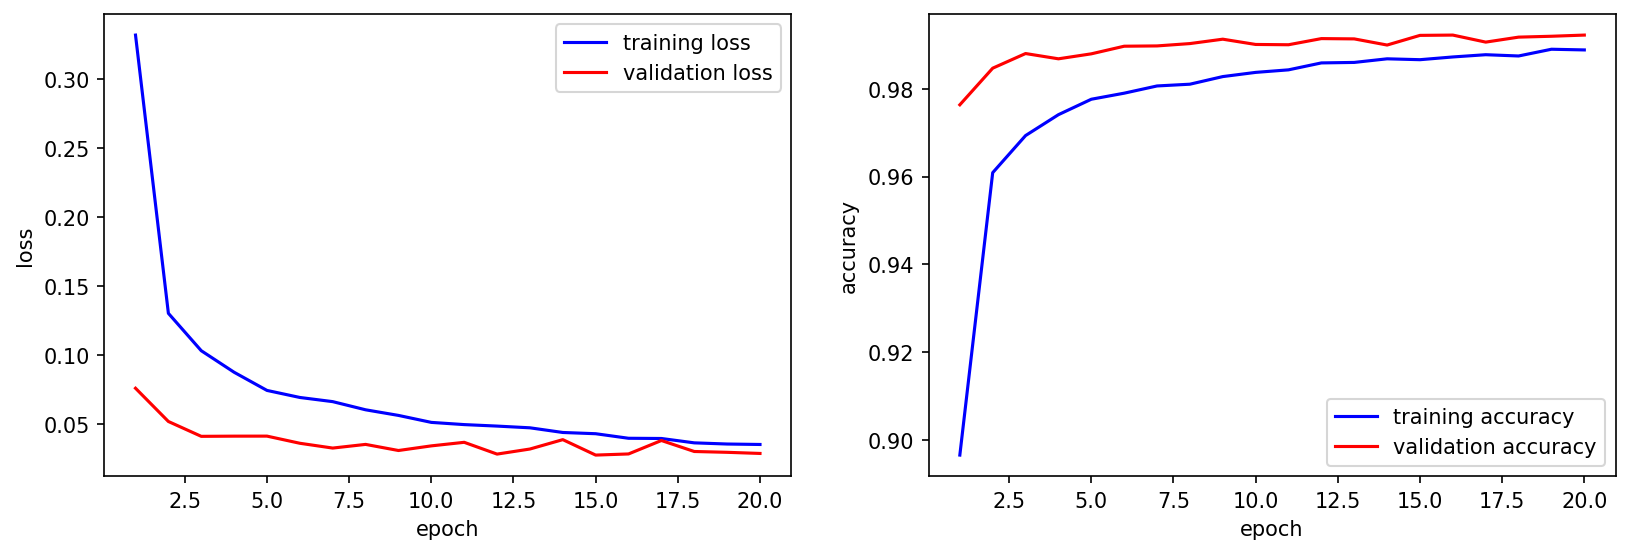

In [ ]:
# plotting the results
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4), dpi=150)
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label ='validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')


plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label ='training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label ='validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')


best_mnist_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_mnist_model.evaluate(X_test, y_test_1_hot,verbose=1)
print('Test accuracy of the model with the lowest loss (the best model)= {:.3f}'.format(accuracy))

# With global averaging
Global average pooling with the number of filters in the last convolutional
layer being equal to the number of classes in the MNIST application.

Epoch 1/20
1404/1407 [============================>.] - ETA: 0s - loss: 1.9323 - accuracy: 0.4046
Epoch 1: val_loss improved from inf to 1.69090, saving model to best_model.keras
1407/1407 [==============================] - 29s 20ms/step - loss: 1.9317 - accuracy: 0.4049 - val_loss: 1.6909 - val_accuracy: 0.5392
Epoch 2/20
1406/1407 [============================>.] - ETA: 0s - loss: 1.5755 - accuracy: 0.5869
Epoch 2: val_loss improved from 1.69090 to 1.47379, saving model to best_model.keras
1407/1407 [==============================] - 28s 20ms/step - loss: 1.5755 - accuracy: 0.5869 - val_loss: 1.4738 - val_accuracy: 0.6235
Epoch 3/20
1404/1407 [============================>.] - ETA: 0s - loss: 1.4092 - accuracy: 0.6471
Epoch 3: val_loss improved from 1.47379 to 1.33708, saving model to best_model.keras
1407/1407 [==============================] - 42s 30ms/step - loss: 1.4090 - accuracy: 0.6472 - val_loss: 1.3371 - val_accuracy: 0.6713
Epoch 4/20
1405/1407 [============================

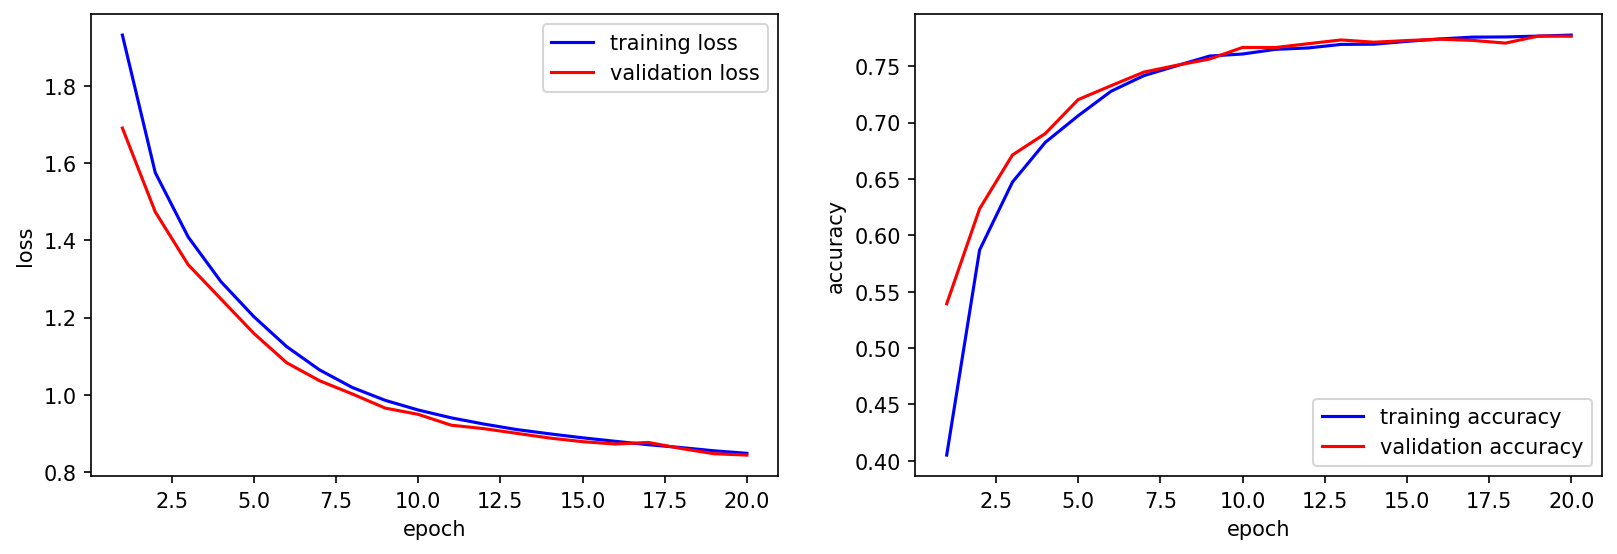

In [ ]:
mnist_model = keras.Sequential([
                              layers.Conv2D(32, 3, activation="relu",input_shape = X_train[0].shape),
                              layers.MaxPooling2D(),
                              layers.Conv2D(10, 3, activation="relu"),
                              layers.MaxPooling2D(),
                              layers.GlobalAveragePooling2D(),
                              keras.layers.Softmax()
                                 ])
# compiling model
mnist_model.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])



# training model
my_callbacks = [
              keras.callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=5),
              keras.callbacks.ModelCheckpoint(
                    filepath="best_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=1)
              ]

start = time.time()

history = mnist_model.fit(x = X_train,
                          y = y_train_1_hot,
                          batch_size = 32,
                          epochs = 20,
                          validation_data = (X_val, y_val_1_hot),
                          callbacks=my_callbacks)

end = time.time()
training_duration = end - start
print("training duration = {:.3f}".format(training_duration))
print(history.history.keys())
print(mnist_model.summary())



# plotting the results
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4), dpi=150)
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label ='validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')


plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label ='training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label ='validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')


best_mnist_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_mnist_model.evaluate(X_test, y_test_1_hot,verbose=1)
print('Test accuracy of the model with the lowest loss (the best model)= {:.3f}'.format(accuracy))

Global average pooling with a “regular” number of filters in the last convolutional
layer and then a dense layer with the same number of neurons as the number
of classes.

In [ ]:
mnist_model = keras.Sequential([
                              layers.Conv2D(16, 3, activation="relu",input_shape = X_train[0].shape),
                              layers.MaxPooling2D(),
                              layers.Conv2D(64, 3, activation="relu"),
                              layers.MaxPooling2D(),
                              layers.GlobalAveragePooling2D(),
                              layers.Dense(10, activation="softmax")
                               ])
# compiling model
mnist_model.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])



# training model
my_callbacks = [
              keras.callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=5),
              keras.callbacks.ModelCheckpoint(
                    filepath="best_model.keras",
                    monitor="val_loss",
                    save_best_only=True,
                    verbose=1)
              ]

start = time.time()

history = mnist_model.fit(x = X_train,
                          y = y_train_1_hot,
                          batch_size = 32,
                          epochs = 200,
                          validation_data = (X_val, y_val_1_hot),
                          callbacks=my_callbacks)

end = time.time()
training_duration = end - start
print("training duration = {:.3f}".format(training_duration))
print(history.history.keys())
print(mnist_model.summary())



# plotting the results
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4), dpi=150)
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label ='validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')


plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label ='training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label ='validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')


best_mnist_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_mnist_model.evaluate(X_test, y_test_1_hot,verbose=1)
print('Test accuracy of the model with the lowest loss (the best model)= {:.3f}'.format(accuracy))

# Recurrent neural network

Prevous NN are all input to output in static way (feedforwd network)

RNN is different such that the output is not only depends on input but also on the history of output too.
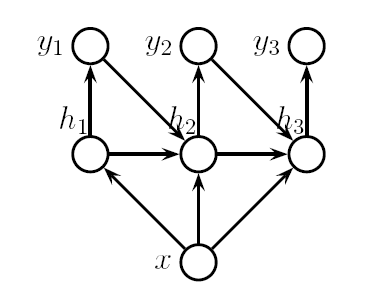




$\mathbf{x}_t$ is $p\times 1$ input

$\mathbf{h}_t$ is $l\times 1$ hidden states

$\mathbf{y}_t$ is $q\times 1$ outputs


## Standard RNN  versus Stacked RNN


$h_t = f_h(W_{xh} x_t +W_{hh} h_{t-1} +b_h)$

$W_{xh}$ input weight matrix

$W_{hh}$ recurrent weight matrix

$y_t=W_{hy} h_t +b_y$

$W_{hy}$ recurrent weight matrix


`keras.layers.simpleRNN`
Above is for one unit

##stacked
$j = 1; ... ; N,$ and $t = 1; ... ; T,$ $h^0_t=x_t$

We can have more units stacked on top of each other

$h^j_t = f_h(W_{h^{j-1}h^{j}} h^{j-1}_t +W_{h^j h^j} h^j_{t-1} +b^j_h)$

$y_t=W_{h^N y} h^N_t +b_y$

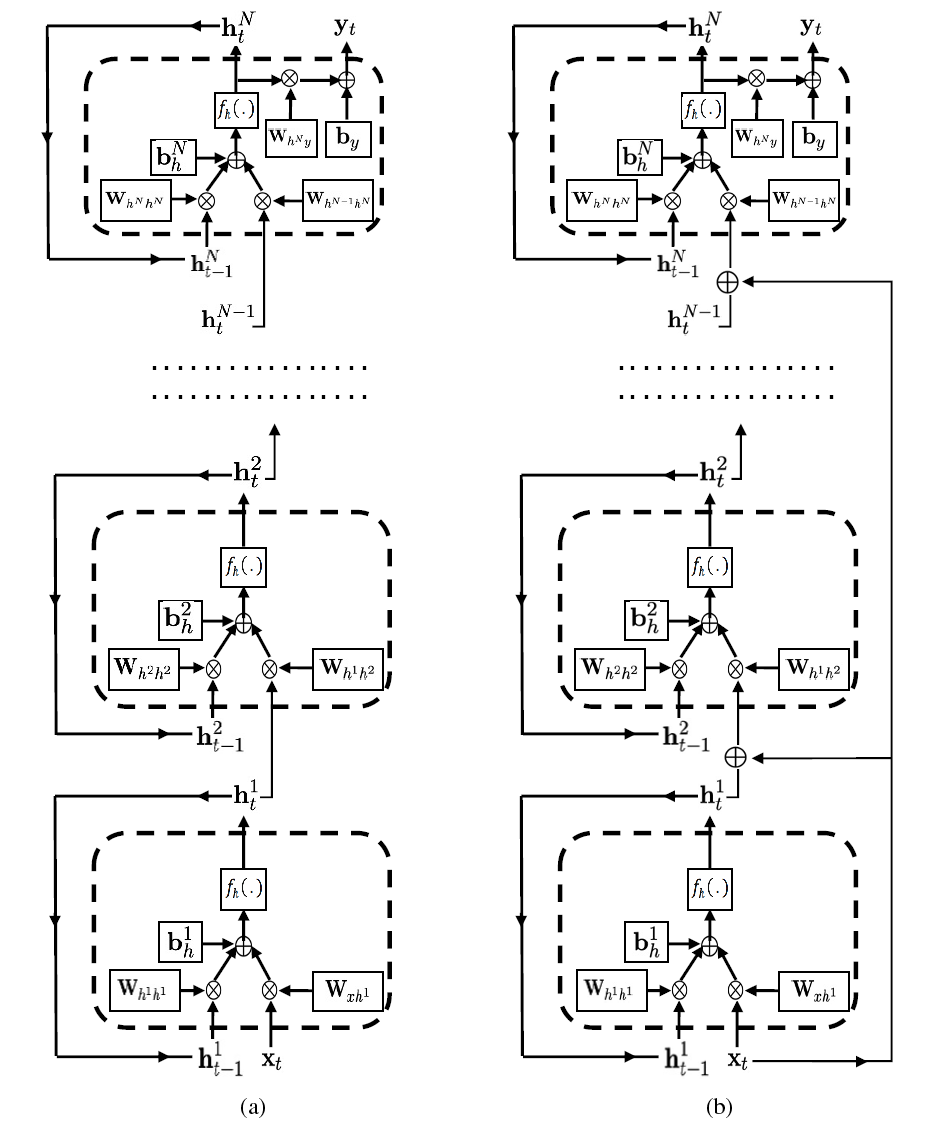



## long short-term memory (LSTM)
## gated recurrent netwrok (GRN)

$h^j_t = f_h(W_{h^{j-1}h^{j}} h^{j-1}_t +W_{h^j h^j} h^j_{t-1} +b^j_h)$

$y_t=\sum_{j=1}^N W_{h^j y} h^j_t +b_y$

$h^j_t = f_h(W_{h^{j-1}h^{j}} h^{j-1}_t +W_{h^j h^j} h^j_{t-1} + W_{xh^j}x_t +b^j_h)$

$y_t=W_{h^N y} h^N_t +b_y$

Single standard RNN
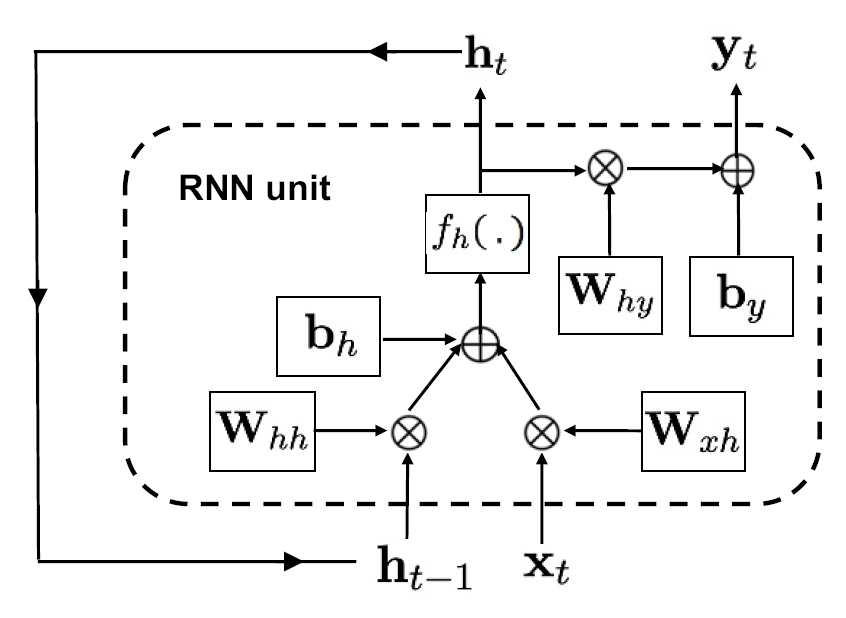


Vanilla RNN have a problem with **gradient exploding**: can be resolved
by the gradient clipping.
*   clipping the norm of the gradient when it is larger than a threshold (e.g., the average norm over a number of updates)

A more sophisticated way is and therefore better version for practice is
*   **long short-term memory (LSTM) units** (Hochreiter and Schmidhuber, 1997), and
*  a more recent one, **gated recurrent units (GRUs)** (Cho et al., 2014),

In both we modify the transition from $x_t$ and $h_{t-1}$ to $h_t$
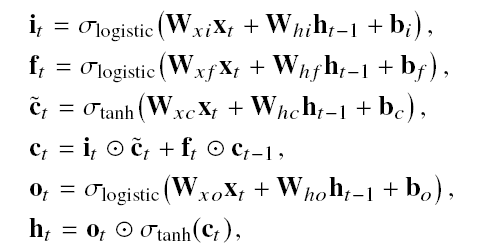

$i_t$ state of input gate

$f_t$  forget gate

$c_t$  memory cell

$o_t$ output gate


In GRUs

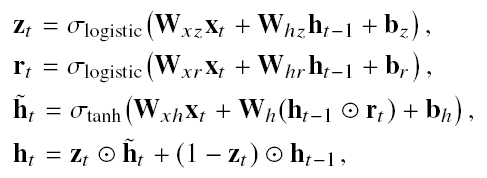

$z_t$ update gate

$r_t$ reset gate



In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
#from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
seed_value= 42

# set the seed for Python built-in pseudo-random generator
import random
random.seed(seed_value)

# set the seed for numpy pseudo-random generator
import numpy as np
np.random.seed(seed_value)

# set the seed for tensorflow pseudo-random generator
tf.random.set_seed(seed_value)

Read database

Here we use concatenate method to add the negative reviews to positive reviews


sampel input
Brilliant over-acting by Lesley Ann Warren. Best dramatic hobo lady I have ever seen, and love scenes in clothes warehouse are second to none. The corn on face is a classic, as good as anything in Blazing Saddles. The take on lawyers is also superb. After being accused of being a turncoat, selling out his boss, and being dishonest the lawyer of Pepto Bolt shrugs indifferently "I'm a lawyer" he says. Three funny words. Jeffrey Tambor, a favorite from the later Larry Sanders show, is fantastic here too as a mad millionaire who wants to crush the ghetto. His character is more malevolent than usual. The hospital scene, and the scene where the homeless invade a demolition site, are all-time classics. Look for the legs scene and the two big diggers fighting (one bleeds). This movie gets better each time I see it (which is quite often).

its output is 1

In [ ]:
!wget http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar xvzf aclImdb_v1.tar.gz

In [ ]:
# load the training (+ validation) data for positive and negative reviews, concatenate them, and generate the labels
directory = "./aclImdb/train/pos" # replace ... by the path to "aclImdb", which contains the downloaded data
X_train_val_pos = keras.utils.text_dataset_from_directory(directory=directory, batch_size = None,label_mode=None, shuffle=False)

directory = "./aclImdb/train/neg"
X_train_val_neg = keras.utils.text_dataset_from_directory(directory=directory, batch_size = None,label_mode=None, shuffle=False)

X_train_val = X_train_val_pos.concatenate(X_train_val_neg)
y_train_val = np.array([0]*len(X_train_val_pos) +[1]*len(X_train_val_neg))

Found 12500 files.
Found 12500 files.


In [ ]:
# load the test data for positive and negative reviews, concatenate them, and generate the labels
directory = "./aclImdb/test/pos"
X_test_pos = keras.utils.text_dataset_from_directory(directory=directory, batch_size = None,label_mode=None, shuffle=False)
directory = "./aclImdb/test/neg"
X_test_neg = keras.utils.text_dataset_from_directory(directory=directory, batch_size = None,label_mode=None, shuffle=False)
X_test = X_test_pos.concatenate(X_test_neg)
y_test = np.array([0]*len(X_test_pos) + [1]*len(X_test_neg))

Found 12500 files.
Found 12500 files.


In [ ]:
# use TextVectorization to learn (by "adapt()" method) the vocabulary from X_train_val
# standardization  which replace puncttuations with space
# tokenization: slpit the text based on spaces
# basically we are trying to learn the vocabulary of the input
from tensorflow.keras.layers import TextVectorization as TV
vocab_size = 5000
tv = TV(max_tokens=vocab_size, output_mode='int')
tv.adapt(X_train_val)
print("Total number of words in the dictionary: ", len(tv.get_vocabulary()))

Total number of words in the dictionary:  5000


In [ ]:
# encode each sequence ("seq") that is part of the X_train_val Dataset object using the learned vocabulary
X_train_val_int_encoded_var_len = []
for seq in X_train_val:
	seq_encoded = tv([seq]).numpy()[0]
	X_train_val_int_encoded_var_len.append(seq_encoded)


TypeError: '_ConcatenateDataset' object is not subscriptable

In [ ]:
X_train_val_int_encoded_var_len[0]

array([   1,  322,    7,    4, 1078,  220,    9, 2085,   31,    2,  167,
         62,   15,   47,   81,    1,   43,  400,  119,  136,   15, 4894,
         56,    1,  148,    8,    2, 4946,    1,  480,   70,    6,  256,
         12,    1,    1, 1972,    7,   73, 2363,    6,  641,   71,    7,
       4894,    2,    1,    6, 2031,    1,    2,    1, 1422,   37,   69,
         68,  205,  141,   65, 1216, 4894,    1,    2,    1,    5,    2,
        219,  904,   32, 2929,   70,    5,    2, 4711,   10,  672,    3,
         65, 1422,   51,   10,  208,    2,  383,    8,   60,    4, 1474,
       3622,  775,    6, 3580,  187,    2,  400,   10, 1192,    1,   31,
        322,    4,  350,  363, 2971,  142,  132,    6,    1,   29,    5,
        123, 4894, 1474, 2409,    6,    1,  322,   10,  517,   12,  106,
       1471,    5,   56,  582,  103,   12,    1,  322,    7,  234,    1,
         49,    4, 2292,   12,    9,  207])

In [ ]:
# decode an encoded sequence back to words
inverse_vocabulary = dict(enumerate(tv.get_vocabulary()))
decoded_sentence = " ".join(inverse_vocabulary[i] for i in X_train_val_int_encoded_var_len[0])
decoded_sentence

'[UNK] high is a cartoon comedy it ran at the same time as some other [UNK] about school life such as teachers my [UNK] years in the teaching [UNK] lead me to believe that [UNK] [UNK] satire is much closer to reality than is teachers the [UNK] to survive [UNK] the [UNK] students who can see right through their pathetic teachers [UNK] the [UNK] of the whole situation all remind me of the schools i knew and their students when i saw the episode in which a student repeatedly tried to burn down the school i immediately [UNK] at high a classic line inspector im here to [UNK] one of your teachers student welcome to [UNK] high i expect that many adults of my age think that [UNK] high is far [UNK] what a pity that it isnt'

In [ ]:
# encode each sequence ("seq") that is part of the X_test Dataset object using the learned vocabulary
X_test_int_encoded_var_len = []
for seq in X_test:
	seq_encoded = tv([seq]).numpy()[0]
	X_test_int_encoded_var_len.append(seq_encoded)
X_test_int_encoded_var_len[0]

array([  10,  418,    3,  208,   11,   18,  226,  311,  101,  107,    1,
          6,   33,    4,  164,  340,    5, 1946,  527,  934,   12,   10,
         14,    1,    6,   68,    9,   80,   36,   49,   10,  672,    5,
          1,    1,   27,   14,   61,  491,    6,   82,  220,   10,   14,
        359,    1,  251,    2,  109,    5, 3216,    1,   53,   74,    3,
       1785,    1,  251, 1001,    1,   17,  136,    1,    2, 1890,    5,
          4,   50,   18,    7,   12,    9,   69, 3006,   17,  254, 1400,
         11,   29,  117,  593,   12,    2,  417,  740,   60,   14, 2940,
         46,   14, 3000,   33, 2162,  299,    2,   86,  357,    5,    2,
         18,    3,   66, 1614,    6, 1670,  299,    2,  326,  357,  131,
          1,    2,  740,   10,   22,   61,  208,  106,  362,    8, 1670,
         19,  106,  371, 2269,  346,   15,   74,  258, 2660,   22,    6,
        372,  253,   68,   98, 2570,   11,   18,   14,   85,    3,   10,
       1405,   12,   23,  138,   68,    9,  156,   

to deal with sequences with different length, we use encoding sequence

Basically we cut long lines and pad short sequence with seros

In [ ]:
# unify the length of each encoded review to a sequence_len. If the review is longer, it is cropped and if it is shorter it will padded by zeros (by default)
sequence_len = 200
X_train_val_padded_fixed_len = keras.utils.pad_sequences(X_train_val_int_encoded_var_len, maxlen=sequence_len)
X_test_padded_fixed_len = keras.utils.pad_sequences(X_test_int_encoded_var_len, maxlen=sequence_len)
X_train_val_padded_fixed_len[0:2]

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    1,  322,    7,    4,
        1078,  220,    9, 2085,   31,    2,  167,   62,   15,   47,   81,
           1,   43,  400,  119,  136,   15, 4894,   56,    1,  148,    8,
           2, 4946,    1,  480,   70,    6,  256,   12,    1,    1, 1972,
           7,   73, 2363,    6,  641,   71,    7, 4894,    2,    1,    6,
        2031,    1,    2,    1, 1422,   37,   69,   68,  205,  141,   65,
        1216, 4894,    1,    2,    1,    5,    2,  219,  904,   32, 2929,
          70,    5,    2, 4711,   10,  672,    3,   65, 1422,   51,   10,
         208,    2,  383,    8,   60, 

Up to hear we did all these to unify our inputs from text to integer sequence and unify their length (input $x_t$ to be of size of px1 where p=200

In [ ]:
# split the training+validation data into training set and validationset
X_train, X_val, y_train, y_val =train_test_split(X_train_val_padded_fixed_len, y_train_val,stratify=y_train_val, test_size=0.25)
# build the model
imdb_model = keras.Sequential([
			layers.Embedding(vocab_size, 16),
			layers.GRU(32, input_shape=(None, 1)),
			layers.Dense(1, activation='sigmoid')
			])
# compiling model
imdb_model.compile(optimizer="adam", loss="binary_crossentropy",metrics=["accuracy"])
# training model
my_callbacks = [
                keras.callbacks.EarlyStopping(
                        monitor="val_accuracy",
                        patience=3),
                keras.callbacks.ModelCheckpoint(
                        filepath="best_model.keras",
                        monitor="val_accuracy",
                        save_best_only=True,
                        verbose=1)
                ]
history = imdb_model.fit(x = X_train,
                        y = y_train,
                        batch_size = 32,
                        epochs = 100,
                        validation_data = (X_val, y_val),
                        callbacks=my_callbacks)


print(history.history.keys())

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6435 - loss: 0.5905
Epoch 1: val_accuracy improved from -inf to 0.82016, saving model to best_model.keras
586/586 ━━━━━━━━━━━━━━━━━━━━ 96s 159ms/step - accuracy: 0.6437 - loss: 0.5903 - val_accuracy: 0.8202 - val_loss: 0.4147
Epoch 2/100
586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8507 - loss: 0.3482
Epoch 2: val_accuracy improved from 0.82016 to 0.83520, saving model to best_model.keras
586/586 ━━━━━━━━━━━━━━━━━━━━ 123s 127ms/step - accuracy: 0.8507 - loss: 0.3482 - val_accuracy: 0.8352 - val_loss: 0.3780
Epoch 3/100
586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8889 - loss: 0.2749
Epoch 3: val_accuracy improved from 0.83520 to 0.85152, saving model to best_model.keras
586/586 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - accuracy: 0.8889 - loss: 0.2749 - val_accuracy: 0.8515 - val_loss: 0.3513
Epoch 4/100
586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9184 - loss: 0.2151
Epoch 4: val_accuracy did not i

Plotting the results

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 16)             │          80,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 32)                  │           4,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 254,501 (994.15 KB)

 Trainable params: 84,833 (331.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 169,668 (662.77 KB)

None
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8689 - loss: 0.4870
Test accuracy = 0.854


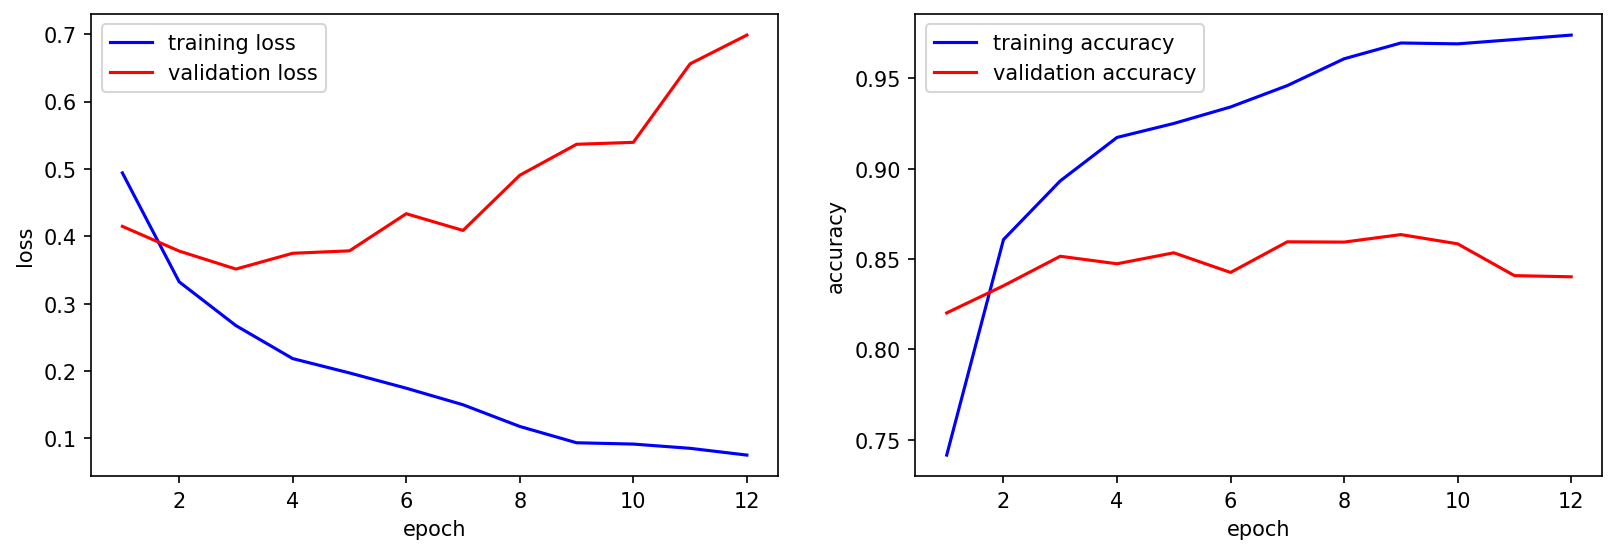

In [ ]:
print(imdb_model.summary())
# plotting the results
epoch_count = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(13,4), dpi=150)
plt.subplot(121)
plt.plot(epoch_count, history.history['loss'], 'b', label = 'training loss')
plt.plot(epoch_count, history.history['val_loss'], 'r', label = 'validation loss')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')

plt.subplot(122)
plt.plot(epoch_count, history.history['accuracy'], 'b', label = 'training accuracy')
plt.plot(epoch_count, history.history['val_accuracy'], 'r', label = 'validation accuracy')
plt.legend()
plt.ylabel('accuracy')
plt.xlabel('epoch')

best_imdb_model = keras.models.load_model("best_model.keras")
loss, accuracy = best_imdb_model.evaluate(X_test_padded_fixed_len,y_test, verbose=1)
print('Test accuracy = {:.3f}'.format(accuracy))

#Exercise:
Redo https://keras.io/examples/timeseries/timeseries_weather_forecasting/

and try GRU instead of LSTM




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import keras

In [ ]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


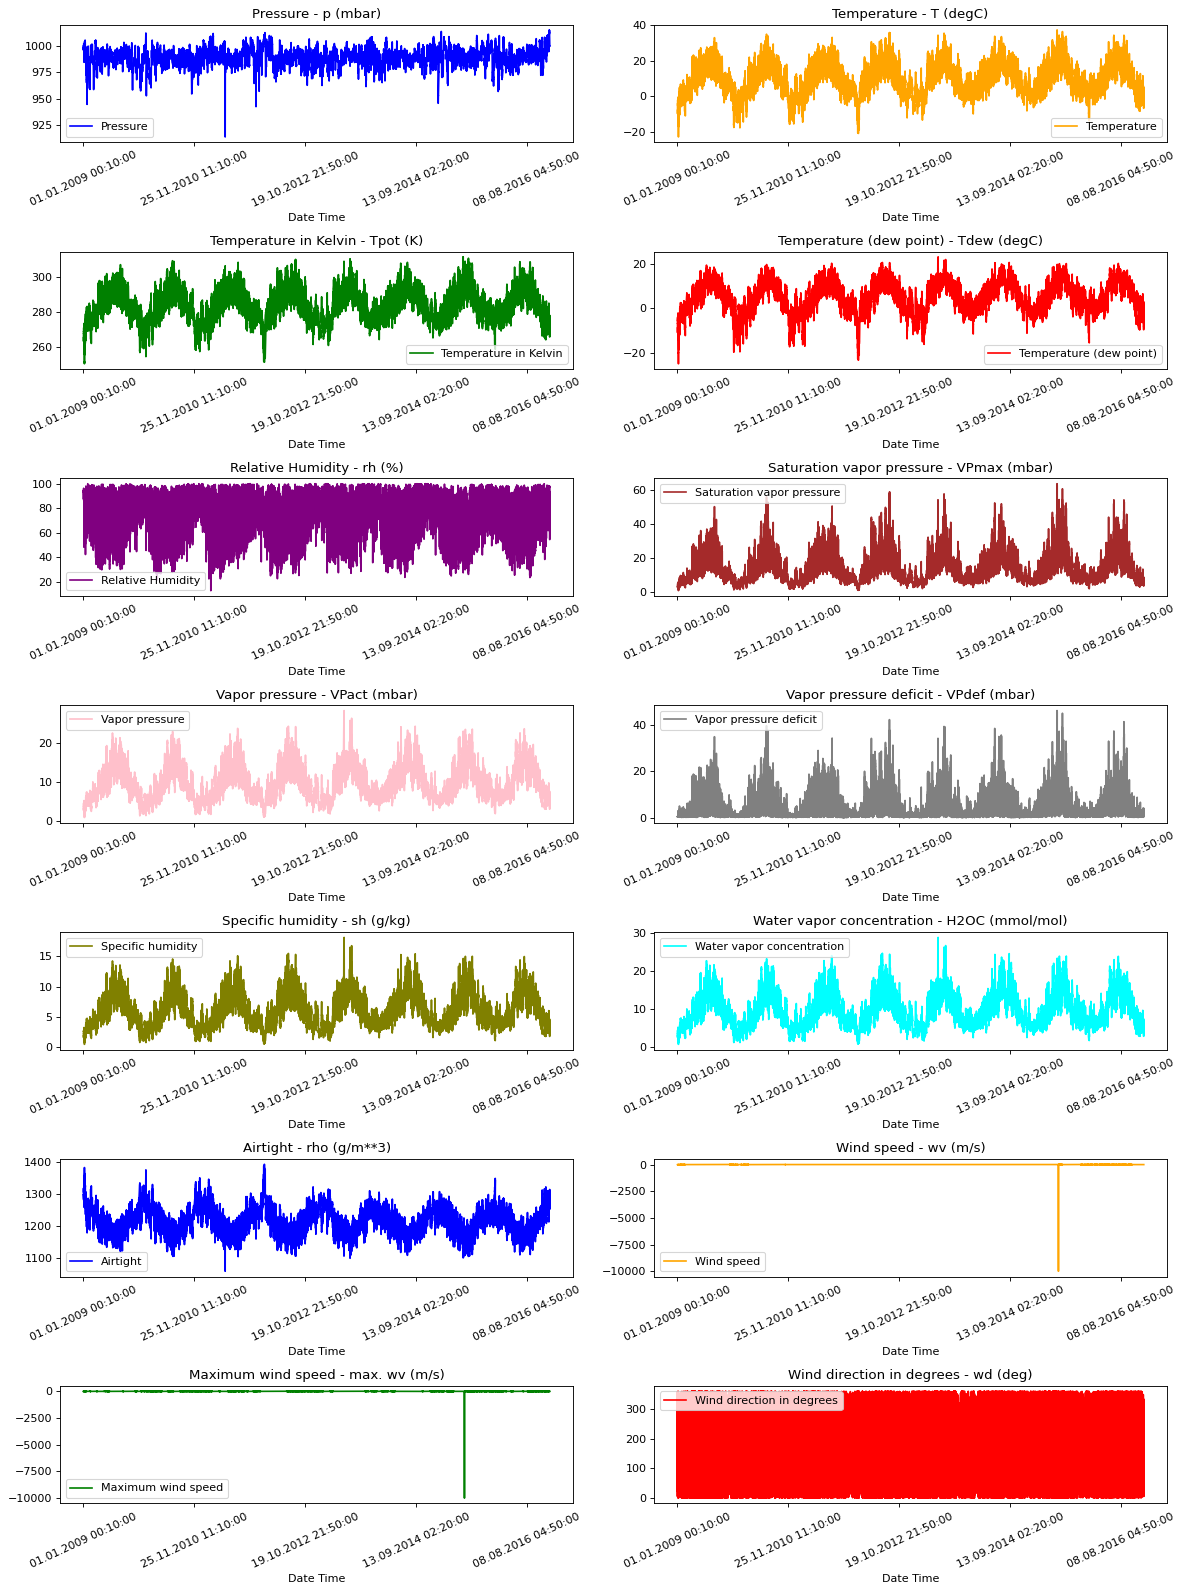

In [ ]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)

**Preprocessing**

In [ ]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10


def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

In [ ]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


# Training Data

In [ ]:
start = past + future
end = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

In [ ]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

# Valdaton Data

In [ ]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


# Training

In [ ]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 120, 7)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.3835
Epoch 1: val_loss improved from inf to 0.16140, saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 198s 165ms/step - loss: 0.3834 - val_loss: 0.1614
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1518
Epoch 2: val_loss improved from 0.16140 to 0.13397, saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1517 - val_loss: 0.1340
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1258
Epoch 3: val_loss improved from 0.13397 to 0.13222, saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1258 - val_loss: 0.1322
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.1218
Epoch 4: val_loss improved from 0.13222 to 0.13148, saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 175s 149ms/step - loss: 0.1218 - val_loss: 0.1315
Epoch 5/10
1

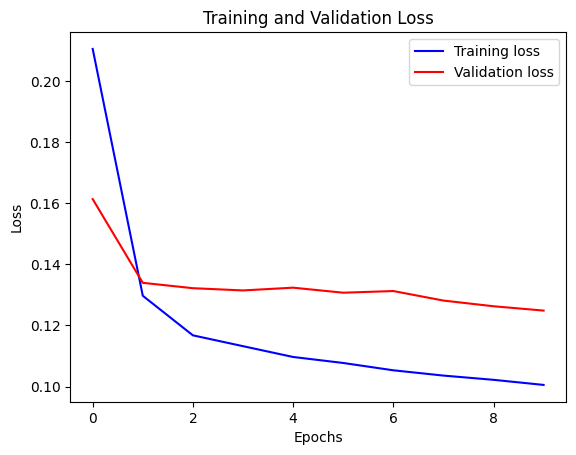

In [ ]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


visualize_loss(history, "Training and Validation Loss")

# Now Let's Test Prediction

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


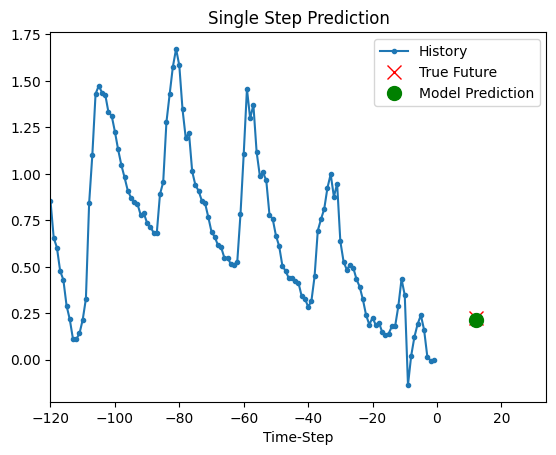

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


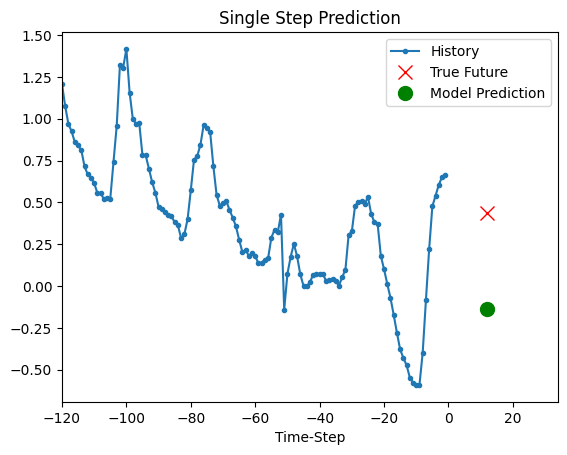

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


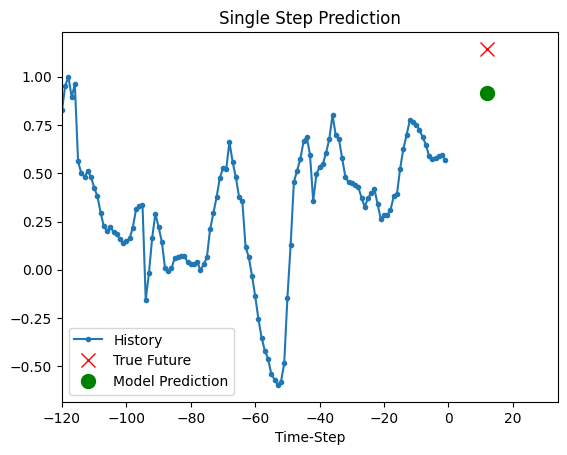

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


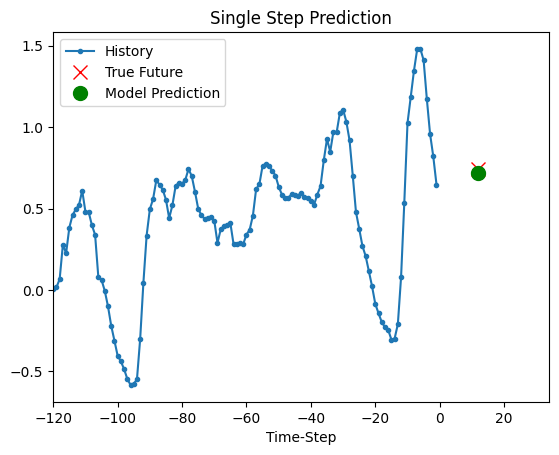

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


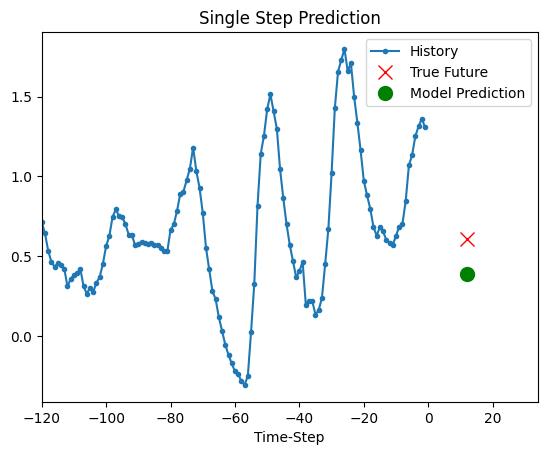

In [ ]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return


for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

# Now Trying GRU instead LSTM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
from zipfile import ZipFile
import numpy as np

In [ ]:
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

# feature columns

In [ ]:
feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

# Select features for the model
print(
    "The selected parameters are:",
    ", ".join([feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df["Date Time"]

The selected parameters are: p (mbar), T (degC), VPmax (mbar), VPdef (mbar), sh (g/kg), rho (g/m**3), wv (m/s)


# Model parameters

In [ ]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6
past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10

# Data normalization and preparation for GRU


In [ ]:
def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

# Normalize features
features = normalize(features.values, train_split)
features = pd.DataFrame(features)


# Spliting Data Here

In [ ]:
train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

# Input Data

In [ ]:
start = past + future
end = start + train_split

In [ ]:
x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

# Create training dataset

In [ ]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

# Prepare validation data

In [ ]:
x_end = len(val_data) - past - future
label_start = train_split + past + future
x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

# Create validation dataset

In [ ]:
dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

# Print input shape for model creation

In [ ]:
for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)


Input shape: (256, 120, 7)
Target shape: (256, 1)


# Model creation functions

In [ ]:
def create_lstm_model(input_shape):
    inputs = keras.layers.Input(shape=input_shape)
    lstm_out = keras.layers.LSTM(32)(inputs)
    outputs = keras.layers.Dense(1)(lstm_out)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
    return model

def create_gru_model(input_shape):
    inputs = keras.layers.Input(shape=input_shape)
    gru_out = keras.layers.GRU(32)(inputs)
    outputs = keras.layers.Dense(1)(gru_out)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
    return model

# Training function

In [ ]:
def train_model(model, dataset_train, dataset_val):
    path_checkpoint = f"{model.name}_checkpoint.weights.h5"
    es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
    modelckpt_callback = keras.callbacks.ModelCheckpoint(
        monitor="val_loss",
        filepath=path_checkpoint,
        verbose=1,
        save_weights_only=True,
        save_best_only=True,
    )
    history = model.fit(
        dataset_train,
        epochs=epochs,
        validation_data=dataset_val,
        callbacks=[es_callback, modelckpt_callback],
    )
    return history

# Visualization functions

In [ ]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [ ]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.figure(figsize=(10, 6))
    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.ylabel("Normalized Temperature")
    plt.grid(True)
    plt.show()

# Train LSTM and GRU models

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.3086
Epoch 1: val_loss improved from inf to 0.16680, saving model to functional_1_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 218s 183ms/step - loss: 0.3085 - val_loss: 0.1668
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1478
Epoch 2: val_loss improved from 0.16680 to 0.14100, saving model to functional_1_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1478 - val_loss: 0.1410
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1219
Epoch 3: val_loss did not improve from 0.14100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 147ms/step - loss: 0.1219 - val_loss: 0.1462
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1173
Epoch 4: val_loss did not improve from 0.14100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 172s 146ms/step - loss: 0.1173 - val_loss: 0.1438
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.1142
Epoch 5: val_loss improve

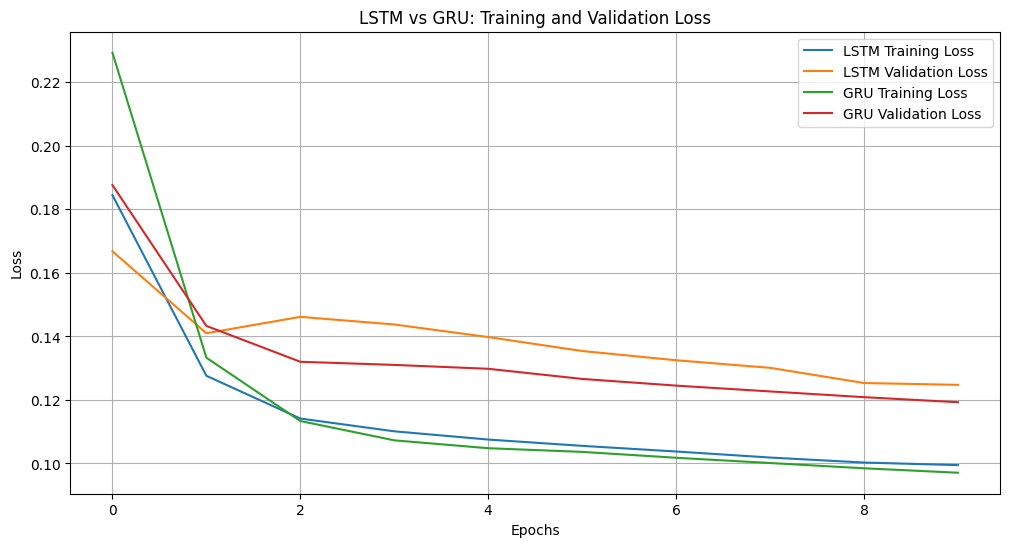

In [ ]:
lstm_model = create_lstm_model((inputs.shape[1], inputs.shape[2]))
gru_model = create_gru_model((inputs.shape[1], inputs.shape[2]))

lstm_history = train_model(lstm_model, dataset_train, dataset_val)
gru_history = train_model(gru_model, dataset_train, dataset_val)

# Comparative loss plot
plt.figure(figsize=(12, 6))
plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
plt.plot(gru_history.history['loss'], label='GRU Training Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss')
plt.title('LSTM vs GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Prediction comparison

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


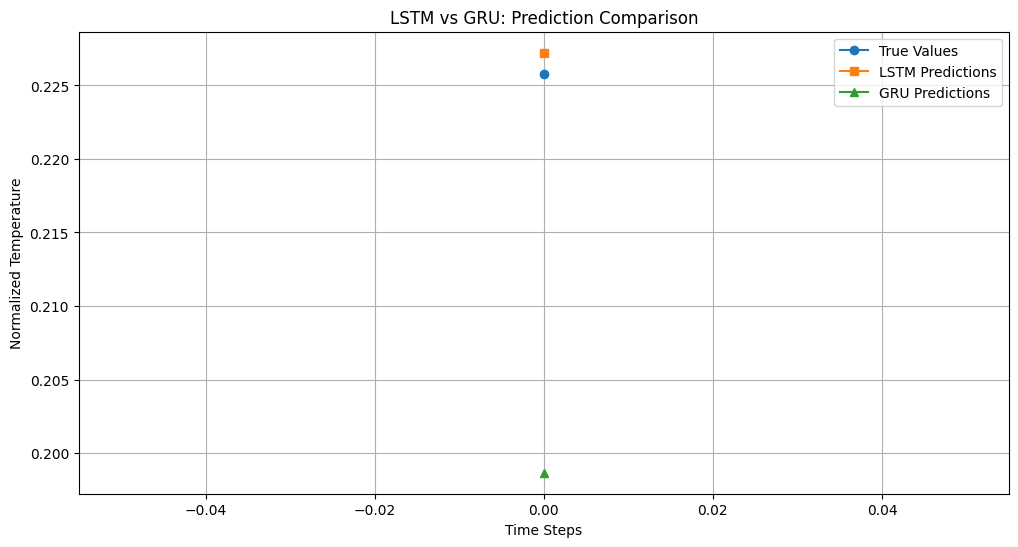

In [ ]:
def compare_predictions(lstm_model, gru_model, dataset_val):
    for x, y in dataset_val.take(1):
        lstm_pred = lstm_model.predict(x)
        gru_pred = gru_model.predict(x)

        plt.figure(figsize=(12, 6))
        plt.plot(y[0].numpy(), label='True Values', marker='o')
        plt.plot(lstm_pred[0], label='LSTM Predictions', marker='s')
        plt.plot(gru_pred[0], label='GRU Predictions', marker='^')
        plt.title('LSTM vs GRU: Prediction Comparison')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Temperature')
        plt.legend()
        plt.grid(True)
        plt.show()

compare_predictions(lstm_model, gru_model, dataset_val)

# Performance metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:
def calculate_metrics(model, dataset):
    true_values = []
    predictions = []
    for x, y in dataset:
        true_values.extend(y.numpy().flatten())
        predictions.extend(model.predict(x).flatten())

    true_values = np.array(true_values)
    predictions = np.array(predictions)

    mse = mean_squared_error(true_values, predictions)
    mae = mean_absolute_error(true_values, predictions)
    return mse, mae

lstm_mse, lstm_mae = calculate_metrics(lstm_model, dataset_val)
gru_mse, gru_mae = calculate_metrics(gru_model, dataset_val)

print("LSTM - MSE:", lstm_mse, "MAE:", lstm_mae)
print("GRU - MSE:", gru_mse, "MAE:", gru_mae)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8/8 ━━━━━━━━

# Bar plot of performance metrics

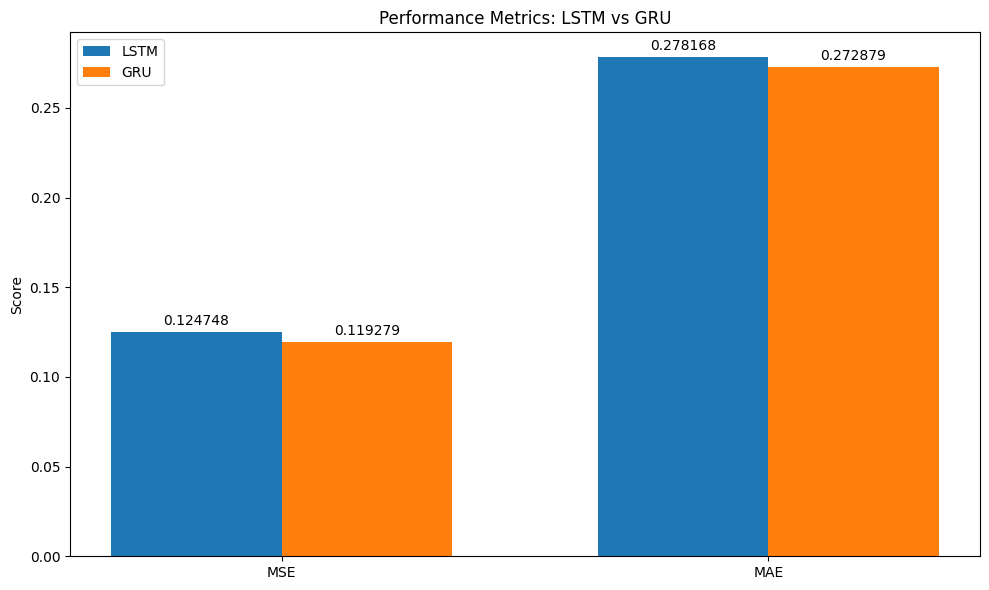

In [ ]:
metrics = ['MSE', 'MAE']
lstm_scores = [lstm_mse, lstm_mae]
gru_scores = [gru_mse, gru_mae]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lstm_scores, width, label='LSTM')
rects2 = ax.bar(x + width/2, gru_scores, width, label='GRU')

ax.set_ylabel('Score')
ax.set_title('Performance Metrics: LSTM vs GRU')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

## References:  
A more detailed text for read [link](https://drive.google.com/file/d/1pzbA_bPsv_UXSZZKOuRzKWuVTO4MlQFG/view?usp=sharing)

## recording
[link Video](https://fsu.zoom.us/rec/share/hwoYYq8GxbOrFFadNcJre_4r8bGPDRJCNZs162H77vsNbRTniz8WjzeFb0WNh825.O_GJoXg8kLnr6j_P)